In [2]:
# Imports 
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 12,
                 'axes.spines.right': False,
                 'axes.spines.top': False,
                 'axes.linewidth':1.2,
                 'xtick.major.size': 6,
                 'xtick.major.width': 1.2,
                 'ytick.major.size': 6,
                 'ytick.major.width': 1.2,
                 'legend.frameon': False,
                 'legend.handletextpad': 0.1,
                 'figure.figsize': [10.0, 3.0],
                 'svg.fonttype': 'none',
                 'text.usetex': False})

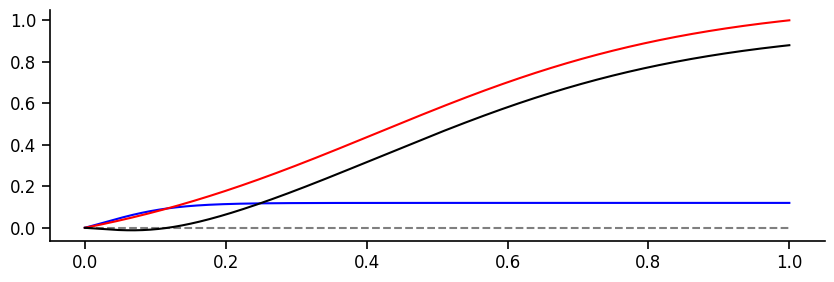

In [3]:
# Load BTSP rule

def get_scaled_rectified_sigmoid(th=0.01, peak=0.02, x=None, ylim=None):
    """
    Transform a sigmoid to intersect x and y range limits.
    :param th: float
    :param peak: float
    :param x: array
    :param ylim: pair of float
    :return: callable
    """
    if x is None:
        x = (0., 1.)
    if ylim is None:
        ylim = (0., 1.)
    if th < x[0] or th > x[-1]:
        raise ValueError('scaled_single_sigmoid: th: %.2E is out of range for xlim: [%.2E, %.2E]' % (th, x[0], x[-1]))
    if peak == th:
        raise ValueError('scaled_single_sigmoid: peak and th: %.2E cannot be equal' % th)
    slope = 2. / (peak - th)
    y = lambda x: 1. / (1. + np.exp(-slope * (x - th)))
    start_val = y(x[0])
    end_val = y(x[-1])
    amp = end_val - start_val
    target_amp = ylim[1] - ylim[0]
    sigmoid_func = lambda xi: (target_amp / amp) * (1. / (1. + np.exp(-slope * (np.clip(xi, x[0], x[-1]) - th))) - start_val) + ylim[0]
    return sigmoid_func

learning_rate = 0.5

# BTSP parameters from Milstein el al. (eLife) Fig.7
sig_dep_th = 0.026
sig_dep_width = 0.1
sig_pot_th = 0.415
sig_pot_width = 0.454
k_pot = 1.11
k_dep = 0.425

sig_dep = get_scaled_rectified_sigmoid(sig_dep_th, sig_dep_th + sig_dep_width)
sig_pot = get_scaled_rectified_sigmoid(sig_pot_th, sig_pot_th + sig_pot_width)
sig_dep_ratio = 0.12

x = np.linspace(0,1,1000)
plt.plot(x,sig_dep(x) * sig_dep_ratio,c='b')
plt.plot(x,sig_pot(x),c='r')
plt.plot(x,sig_pot(x)-sig_dep(x)*sig_dep_ratio,c='k')
plt.plot([0,1],[0,0],'k--',alpha=0.5)
plt.show()

def btsp(ET, IS, W, Wmax):
    dW = (Wmax - W) * k_pot * sig_pot(ET.T@IS) - W * k_dep * sig_dep(ET.T@IS)
    return dW


In [4]:
# # 'Classical' BTSP from eLife paper
# sig_dep_th = 0.01
# sig_dep_width = 0.045
# sig_pot_th = 0.5
# sig_pot_width = 0.5
# sig_dep_ratio = 0.12
# k_pot = 1.7
# k_dep = k_pot * sig_dep_ratio

# sig_dep = get_scaled_rectified_sigmoid(sig_dep_th, sig_dep_th + sig_dep_width)
# sig_pot = get_scaled_rectified_sigmoid(sig_pot_th, sig_pot_th + sig_pot_width)

# x = np.linspace(0,1,1000)
# plt.plot(x,sig_dep(x) * sig_dep_ratio,c='b')
# plt.plot(x,sig_pot(x),c='r')
# plt.plot(x,sig_pot(x)-sig_dep(x)*sig_dep_ratio,c='k')
# plt.plot([0,1],[0,0],'k--',alpha=0.5)
# plt.show()

# def btsp(ET, IS, W, Wmax):
#     dW = (Wmax - W) * k_pot * sig_pot(ET.T@IS) - W * k_dep * sig_dep(ET.T@IS)
#     return dW

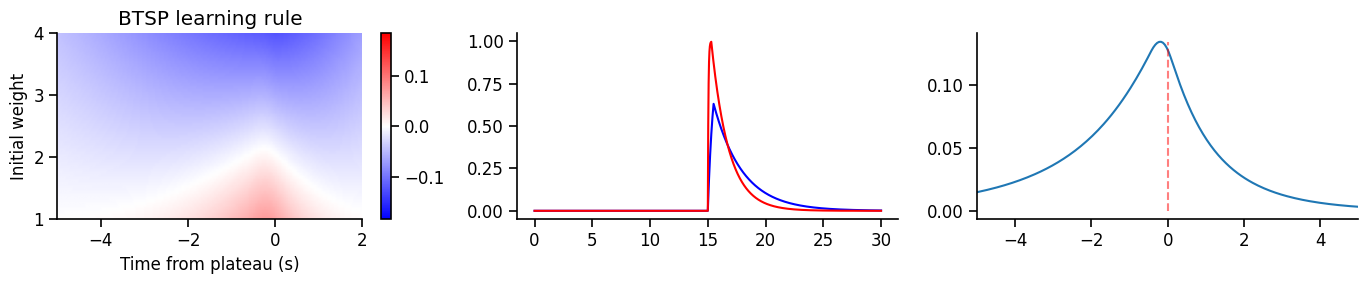

len(ET) 30000 len(IS) 30000


In [5]:
# Plot BTSP learning rule (dW vs time from plateau)

def multiW_btsp(ET, IS, W, Wmax):
    dW = (Wmax - W) * k_pot * sig_pot(ET*IS)[:,None] - W * k_dep * sig_dep(ET*IS)[:,None]
    return np.mean(dW, axis=0)

def plot_btsp_learning_rule(T, ET_rise_tau=0.3, IS_rise_tau=0.05, ET_decay_tau=2.5, IS_decay_tau=1.5):
    ''' Plot BTSP learning rule (dW vs time from plateau) 
    
    :param T: float, dwell time (s)
    :param ET_rise_tau: float, ET rise time constant (s)
    :param ET_decay_tau: float, ET decay time constant (s)
    :param IS_rise_tau: float, IS rise time constant (s)
    :param IS_decay_tau: float, IS decay time constant (s)
    '''

    # Set parameters
    dt = 0.001 # s
    tmax = 30  # s
    Wmax = 5.
    w_init = np.arange(0, Wmax, 0.05)
    plateau_dur = 0.3  # s
    ET_start = 0 # s

    # Generate ET template trace
    t1 = np.arange(0, T, dt)
    ET_rise = 1-np.exp(-t1/ET_rise_tau)
    t2 = np.arange(0, tmax-T, dt)
    ET_decay = ET_rise[-1] * np.exp(-t2/ET_decay_tau)
    ET = np.concatenate((ET_rise, ET_decay))
    ET = np.roll(ET, int((tmax/2+ET_start)/dt)) # start ET in the center of the trace
    # ET = np.roll(ET, int((tmax/2)/dt)) # start ET in the center of the trace

    # Generate IS template trace
    t1 = np.arange(0, plateau_dur, dt)
    IS_rise = 1-np.exp(-t1/IS_rise_tau)
    t2 = np.arange(0, tmax-plateau_dur, dt)
    IS_decay = IS_rise[-1] * np.exp(-t2/IS_decay_tau)
    IS = np.concatenate((IS_rise, IS_decay))
    IS = np.roll(IS, int((tmax/2)/dt)) # start plateau in the center of the trace
    IS[0:int((tmax/2)/dt)] = 0 # zero values before the start of plateau

    # Compute dW matrix
    all_delta_t = np.arange(-tmax/2, tmax/2, 0.05)
    dW = np.zeros((len(w_init), len(all_delta_t)))

    for i, delta_t in enumerate(all_delta_t):
        shifted_ET = np.roll(ET, int(delta_t/dt))
        # zero values before the start of ET rise
        shifted_ET[0:int((delta_t+ET_start+tmax/2)/dt)] = 0
        dW[:, i] = multiW_btsp(shifted_ET, IS, w_init, Wmax)
    dW = np.flip(dW, axis=0)

    # Plot dW matrix, with time relative to plateau on the x-axis and initial weight on the y-axis (going from 0 at the bottom to Wmax at the top)
    fig, ax = plt.subplots(1,3,figsize=(14,3))
    colorscale = np.max(np.abs(dW))
    im = ax[0].imshow(dW, extent=[-tmax/2, tmax/2, 0, Wmax], aspect='auto', cmap='bwr', vmin=-colorscale, vmax=colorscale)
    plt.colorbar(im, ax=ax[0])
    ax[0].set_xlim([-5,2])
    ax[0].set_ylim([1,4])
    ax[0].set_xlabel('Time from plateau (s)')
    ax[0].set_ylabel('Initial weight')
    ax[0].set_title('BTSP learning rule')

    time = np.arange(0, tmax, dt)
    ET[0:int((ET_start+tmax/2)/dt)] = 0
    ax[1].plot(time, ET, c='b')
    ax[1].plot(time, IS, c='r')

    ax[2].plot(np.linspace(-tmax/2,tmax/2,len(all_delta_t)), dW[99,:])
    ax[2].plot([0,0],[0,max(dW[99,:])],'r--',alpha=0.5)
    ax[2].set_xlim([-5,5])
    plt.tight_layout()
    plt.show()

    print(f"len(ET) {len(ET)} len(IS) {len(IS)}")

    # fig.savefig('figures/Fig4-reinforcement-learning/btsp_learning_rule.png', dpi=300)
    # fig.savefig('figures/Fig4-reinforcement-learning/btsp_learning_rule.svg', dpi=300)


plot_btsp_learning_rule(T=0.5, ET_rise_tau=0.5, IS_rise_tau=0.05, ET_decay_tau=2.5, IS_decay_tau=1.5) # 'Classical' BTSP from eLife paper


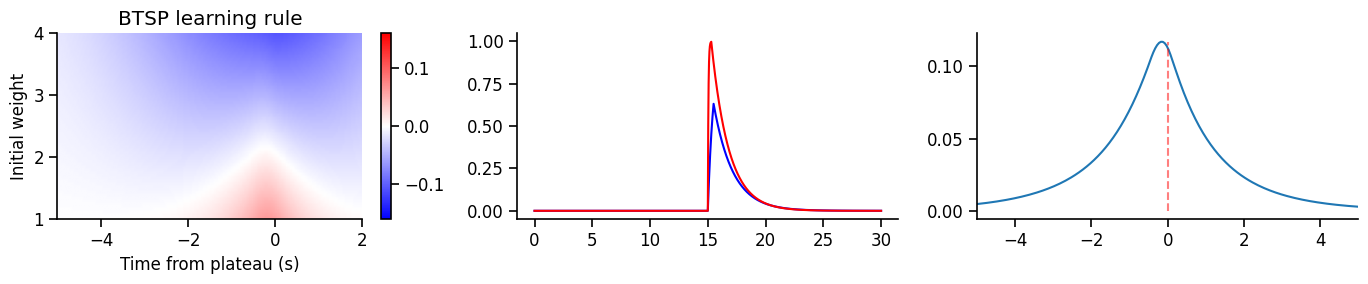

len(ET) 30000 len(IS) 30000


In [6]:
plot_btsp_learning_rule(T=0.5, ET_rise_tau=0.5, IS_rise_tau=0.05, ET_decay_tau=1.66, IS_decay_tau=1.5) # Parameters from eLife Fig.7

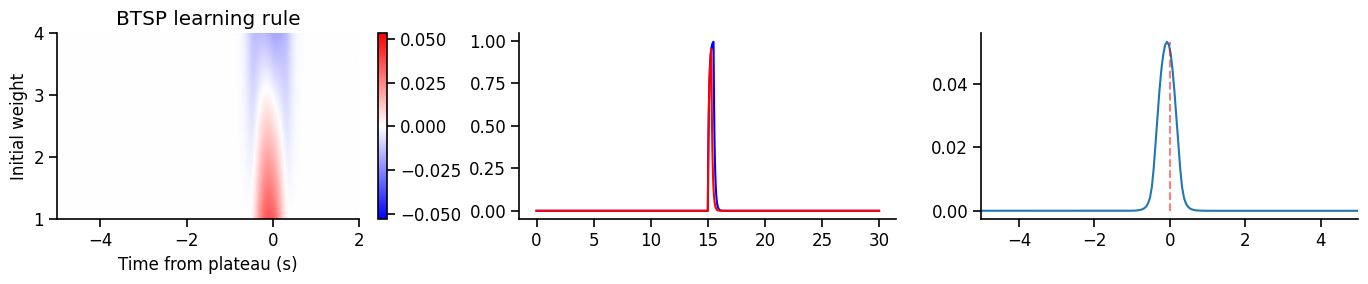

len(ET) 30000 len(IS) 30000


In [7]:
plot_btsp_learning_rule(T=0.5, ET_rise_tau=0.1, IS_rise_tau=0.1, ET_decay_tau=0.1, IS_decay_tau=0.1) # Parameters for short-timescale rule

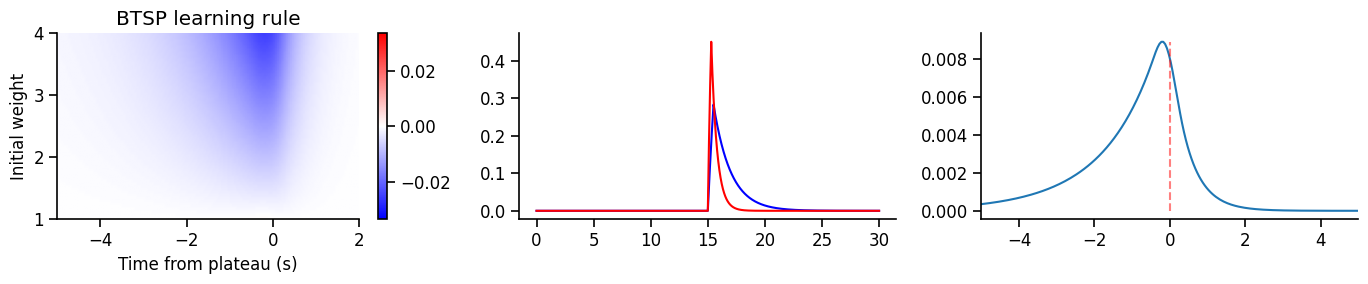

len(ET) 30000 len(IS) 30000


In [8]:
plot_btsp_learning_rule(T=0.5, ET_rise_tau=1.5, IS_rise_tau=0.5, ET_decay_tau=1.5, IS_decay_tau=0.5) # 'Classical' BTSP from eLife paper


In [9]:
from pathlib import Path
import pandas as pd

def load_two_numeric_cols(path):
    p = Path(path).expanduser()
    # 1) Try auto-detect delimiter, handle BOM
    df = pd.read_csv(
        p, sep=None, engine="python", header=None,
        encoding="utf-8-sig",  # handles BOM if present
        comment="#",           # ignore commented lines
        skip_blank_lines=True
    )
    if df.empty:
        raise ValueError(f"Read empty DataFrame from {p}. Check delimiter/encoding.")

    # 2) If there are more than 2 cols, keep the last two
    if df.shape[1] >= 2:
        df = df.iloc[:, -2:]
    else:
        raise ValueError(f"Only {df.shape[1]} column(s) found in {p}, expected 2.")

    # 3) Coerce to numeric, drop any non-numeric rows
    df.columns = ["x", "y"]
    df["x"] = pd.to_numeric(df["x"], errors="coerce")
    df["y"] = pd.to_numeric(df["y"], errors="coerce")
    df = df.dropna(subset=["x", "y"]).reset_index(drop=True)

    if df.empty:
        raise ValueError(f"All rows non-numeric after coercion in {p}.")
    return df

# Use it
df_10  = load_two_numeric_cols("/Users/michaelfinch/btsp_kernels_extracted_biorxiv/backwards_fig_2d_10hz.csv")
df_20  = load_two_numeric_cols("/Users/michaelfinch/btsp_kernels_extracted_biorxiv/backwards_fig_2d_20hz.csv")
df_40  = load_two_numeric_cols("/Users/michaelfinch/btsp_kernels_extracted_biorxiv/backwards_fig_2d_40hz.csv")
df_100  = load_two_numeric_cols("/Users/michaelfinch/btsp_kernels_extracted_biorxiv/backwards_fig_2d_100hz.csv")
df_full = load_two_numeric_cols("/Users/michaelfinch/btsp_kernels_extracted_biorxiv/full_btsp_kernel_fig2c.csv")

print(df_10.head())



          x         y
0 -3.999254  1.171287
1 -2.999116  1.221545
2 -1.998786  1.341392
3 -0.997902  1.662272
4 -0.442750  2.182459


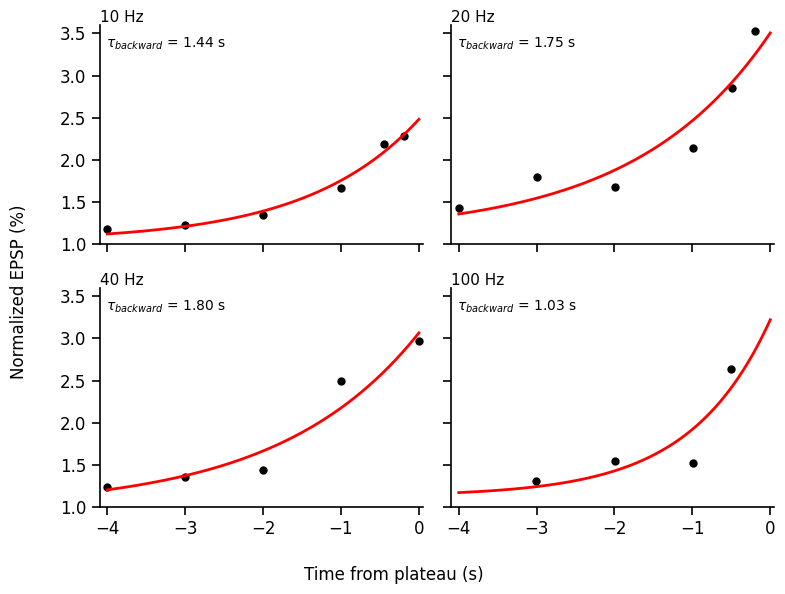

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# --- helpers ---
def get_xyyerr(df):
    x = df.iloc[:, 0].to_numpy(float)
    y = df.iloc[:, 1].to_numpy(float)
    yerr = df.iloc[:, 2].to_numpy(float) if df.shape[1] >= 3 else None
    return x, y, yerr

def fit_A_c_fixed_tau(x, y, tau):
    """Least-squares fit of A and c in y = c + A*exp(x/tau), with tau fixed."""
    Phi = np.column_stack([np.exp(x / tau), np.ones_like(x)])  # [e^{x/tau}, 1]
    coef, *_ = np.linalg.lstsq(Phi, y, rcond=None)
    A, c = coef[0], coef[1]
    return float(A), float(c)

def exp_rise_fixed_tau(x, A, c, tau):
    return c + A*np.exp(x/tau)

def plot_btsp_with_fixed_taus(dfs, taus, titles):
    fig, axes = plt.subplots(2, 2, figsize=(8, 6), sharex=True, sharey=True)
    axes = axes.ravel()

    for ax, df, tau, ttl in zip(axes, dfs, taus, titles):
        x, y, yerr = get_xyyerr(df)

        A, c = fit_A_c_fixed_tau(x, y, tau)

        # curve
        xx = np.linspace(-4.0, 0.0, 400)
        yy = exp_rise_fixed_tau(xx, A, c, tau)

        if yerr is None:
            ax.plot(x, y, "ko", ms=5)
        else:
            ax.errorbar(x, y, yerr=yerr, fmt="o", color="k", ms=5, capsize=3)

        ax.plot(xx, yy, "-", color="red", lw=2)

        # cosmetics similar to figure
        ax.set_xlim(-4.1, 0.05)
        ax.set_ylim(1.0, 3.6)
        ax.set_xticks([-4, -3, -2, -1, 0])
        ax.set_title(ttl, loc="left", fontsize=11, pad=2)
        ax.text(0.02, 0.95, fr"$\tau_{{backward}}$ = {tau:.2f} s",
                transform=ax.transAxes, va="top", ha="left", fontsize=10)

    fig.text(0.5, 0.02, "Time from plateau (s)", ha="center")
    fig.text(0.02, 0.5, "Normalized EPSP (%)", va="center", rotation="vertical")
    plt.tight_layout(rect=(0.06, 0.06, 1, 1))
    plt.show()

dfs   = [df_10, df_20, df_40, df_100]
taus  = [1.44, 1.75, 1.80, 1.03]   # seconds, from the paper
titles = ("10 Hz", "20 Hz", "40 Hz", "100 Hz")

plot_btsp_with_fixed_taus(dfs, taus, titles)



In [11]:
import numpy as np

def spike_train_by_rate(rate_hz=20, n=10, t0_ms=0.0, jitter_ms=0.0, min_isi_ms=0.0,
                        rng=None, rounding="nearest"):
    """
    Generate n integer spike times (ms) for a constant firing rate.
      - rate_hz: spikes/s  (ISI = 1000 / rate_hz ms)
      - t0_ms: start time (ms)
      - jitter_ms: Gaussian jitter std (ms)
      - min_isi_ms: enforce minimum ISI AFTER rounding (ms)
      - rounding: 'nearest' | 'floor' | 'ceil'
    Returns: np.ndarray[int64] of shape (n,)
    """
    if rate_hz <= 0:
        raise ValueError("rate_hz must be > 0")
    rng = np.random.default_rng() if rng is None else rng

    isi_ms = 1000.0 / float(rate_hz)
    times_f = t0_ms + np.arange(n, dtype=float) * isi_ms
    if jitter_ms > 0:
        times_f = times_f + rng.normal(0.0, jitter_ms, size=n)

    if rounding == "nearest":
        times = np.rint(times_f)
    elif rounding == "floor":
        times = np.floor(times_f)
    elif rounding == "ceil":
        times = np.ceil(times_f)
    else:
        raise ValueError("rounding must be 'nearest', 'floor', or 'ceil'")
    times = times.astype(np.int64)

    min_isi_int = int(np.ceil(min_isi_ms))
    if min_isi_int > 0:
        for i in range(1, n):
            min_allowed = times[i-1] + min_isi_int
            if times[i] < min_allowed:
                times[i] = min_allowed

    return times

# spike_times = spike_train_by_rate(rate_hz=100, n=10, t0_ms=0)
# spike_times

# # kernel and causal convolution
# def exp_kernel(tau_ms, dt_ms, n_taus=5, norm="area", target=1.0):
#     klen = int(np.ceil(n_taus * tau_ms / dt_ms))
#     t = np.arange(klen) * dt_ms
#     k = np.exp(-t / tau_ms)
#     if norm == "area": k /= (k.sum() + 1e-12)
#     elif norm == "peak": k /= (k.max() + 1e-12)
#     else: raise ValueError("norm must be 'area' or 'peak'")
#     return k * target

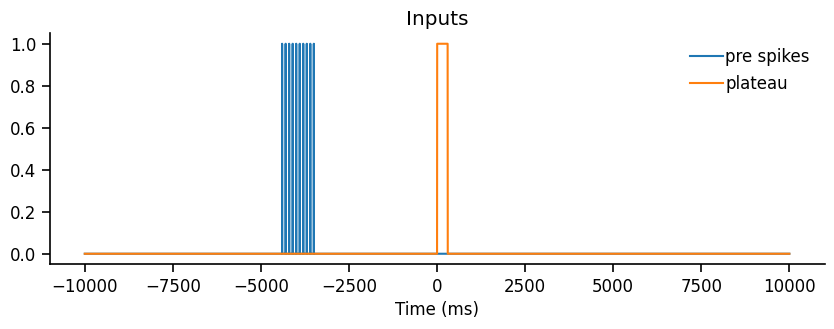

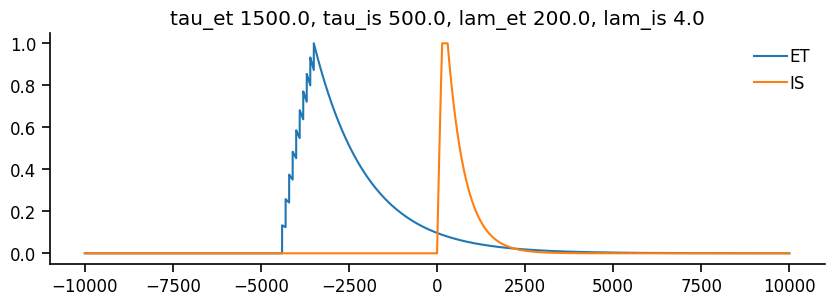

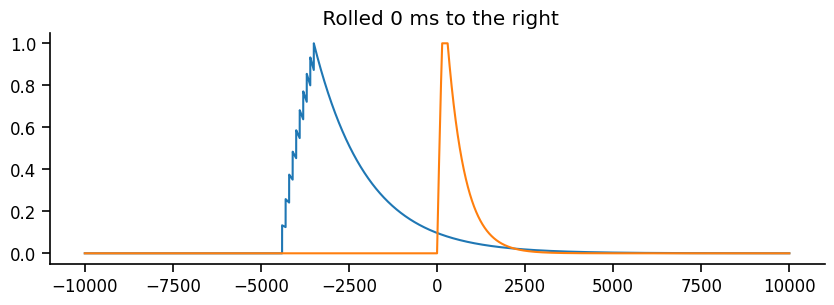

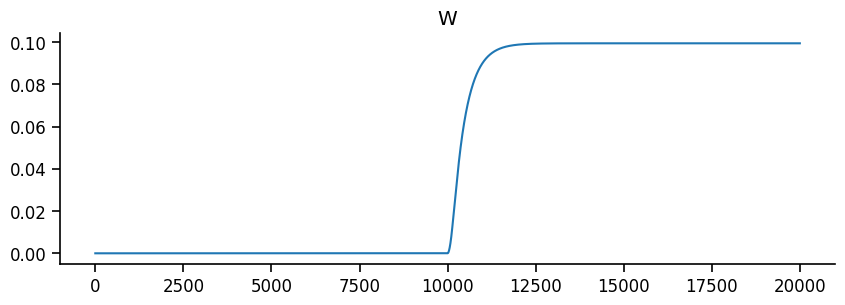

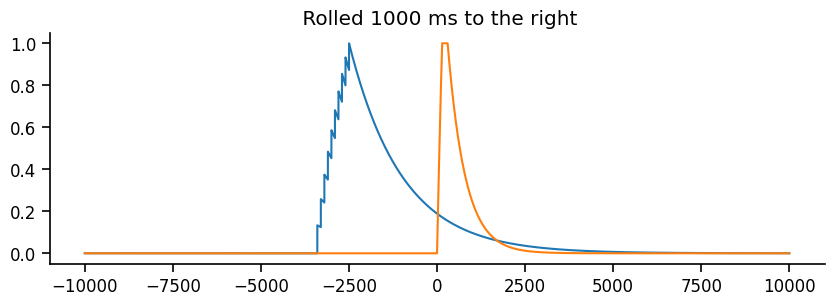

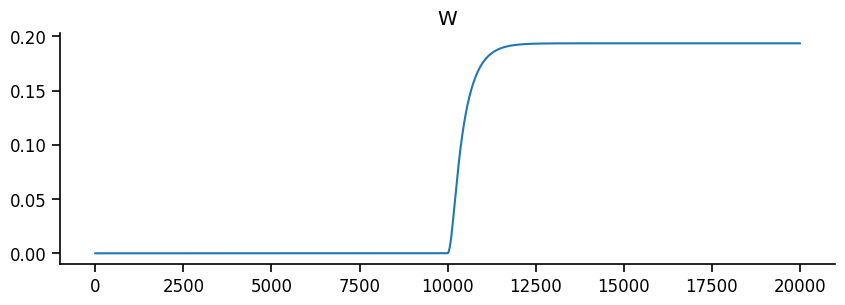

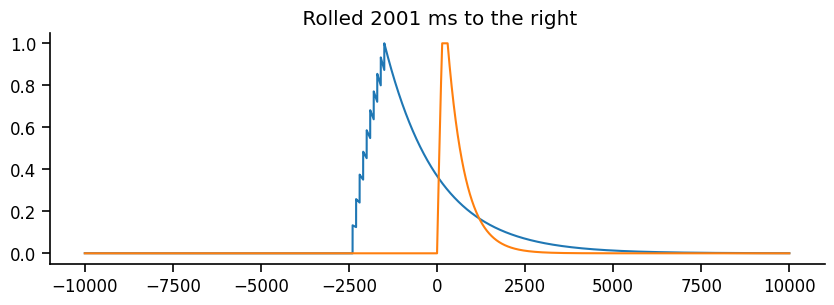

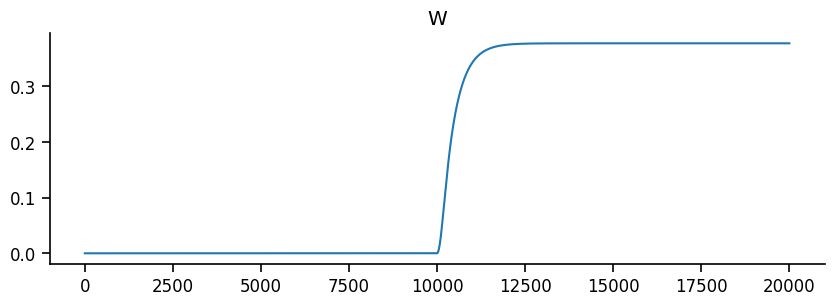

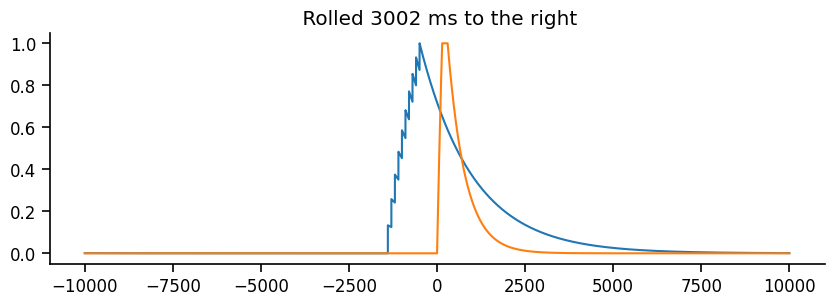

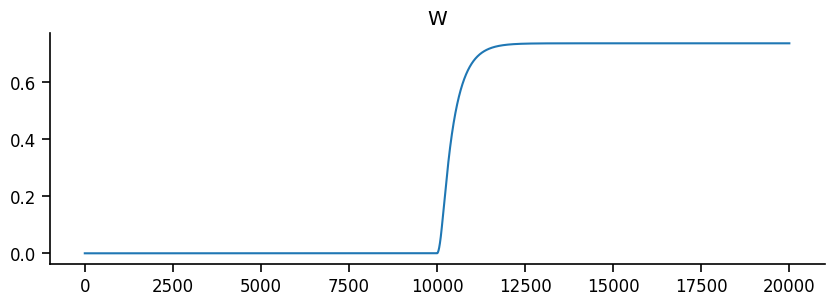

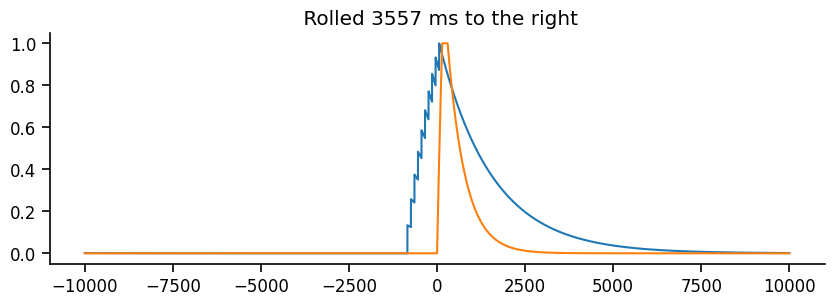

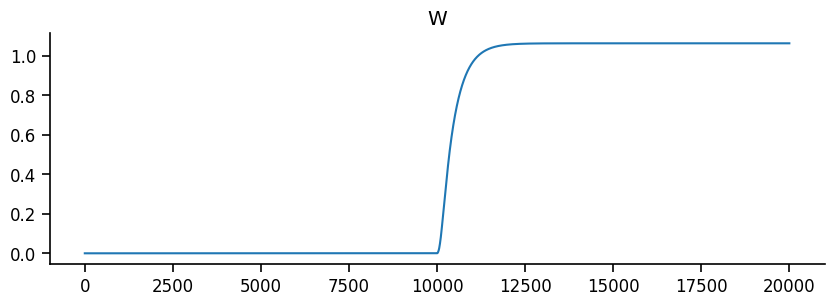

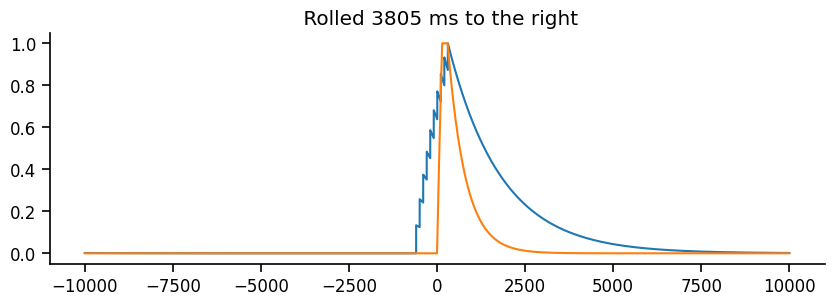

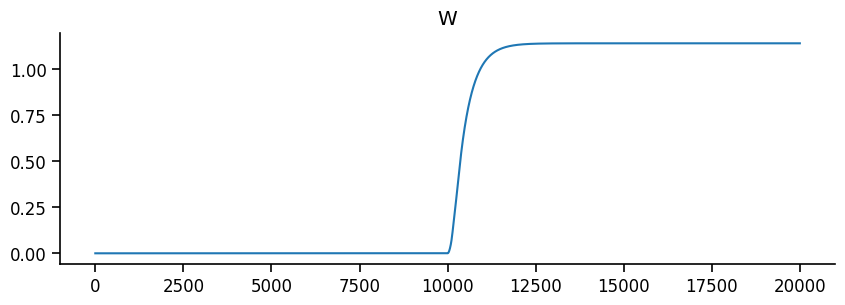

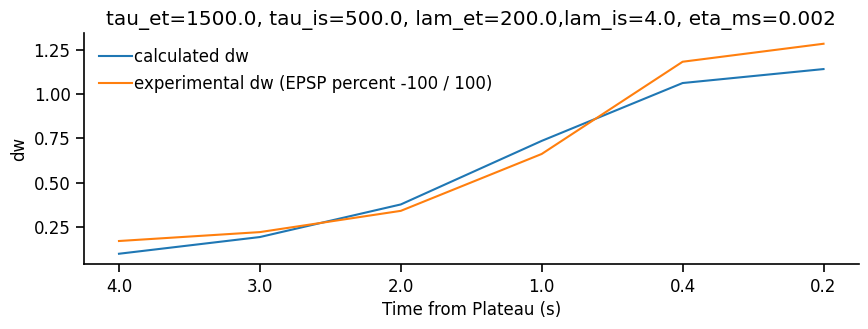

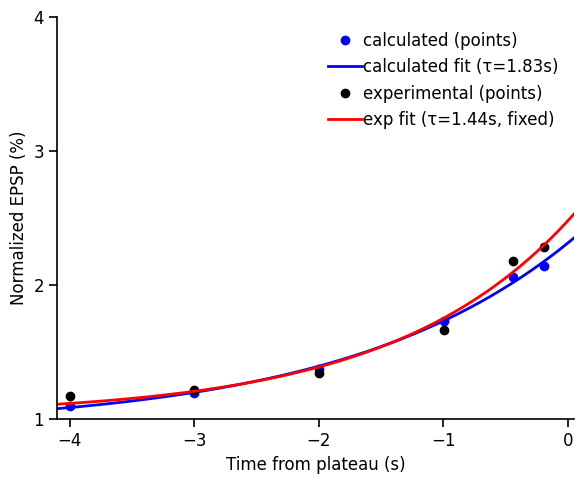

In [12]:


def integrate_weight(ET, IS, eta=1e-4, Wmin=0.0, Wmax=2.0, dt_ms=1.0):
    T = len(ET)
    W = np.empty(T, dtype=float)
    w=0. 
    for t in range(T):
        dWdt = eta * ET[t] * IS[t]      
        w += dWdt * dt_ms  
        # w = np.clip(w, Wmin, Wmax)                    
        W[t] = w
    return W

def multiply_et(spike_train, tau_ms, lam=1.0, dt_ms=1.0):

    ET_over_time = np.empty_like(spike_train)
    ET = 0.0
    one_over_tau = 1.0 / tau_ms
    for t, spike in enumerate(spike_train):
        dEdt = (-ET + lam * spike) * one_over_tau       
        ET+= (dEdt * dt_ms)   
        # ET = np.clip(ET, 0.0, 1.0)     
        ET = min(1.0, ET)
        ET_over_time[t] = ET
    return ET_over_time

def get_W(x_arr_int, post_ms=10000, pre_ms=10000, hz_used=10, plateau_length = 300,tau_et =1500.,tau_is = 500.,lam_et=200.,lam_is=4,dt_ms=1.0, eta_ms = 0.0001, plot_intermediates=True):
   
    time_to_is=x_arr_int[0] 
    spike_times = spike_train_by_rate(rate_hz=hz_used, n=10, t0_ms=0).astype(int)
    mid_spike = spike_times[4]

    T_ms = int(pre_ms + post_ms)
    t_ms = np.arange(-pre_ms, post_ms, dtype=int)
    center_idx = pre_ms  

    offset = center_idx - time_to_is - mid_spike
    spike_idx = offset + spike_times

    spike_train = np.zeros(T_ms)
    spike_train[spike_idx] = 1.0

    # valid = (spike_idx >= 0) & (spike_idx < T_ms)
    # spike_train[spike_idx[valid]] = 1.0

    is_pre_conv = np.zeros(T_ms)
    is_pre_conv[center_idx:center_idx+plateau_length] =1

    if plot_intermediates:
        plt.plot(t_ms,spike_train, label='pre spikes')
        plt.plot(t_ms,is_pre_conv, label="plateau")
        plt.title("Inputs")
        plt.xlabel("Time (ms)")
        plt.legend()
        plt.show()
    
    ET = multiply_et(spike_train, tau_ms=tau_et, lam=lam_et, dt_ms=dt_ms)

    IS= multiply_et(is_pre_conv, tau_ms=tau_is, lam=lam_is, dt_ms=1.0)



    if plot_intermediates:
        plt.plot(t_ms, ET, label="ET")
        plt.plot(t_ms, IS, label="IS")
        plt.title(f"tau_et {tau_et}, tau_is {tau_is}, lam_et {lam_et}, lam_is {lam_is}")
        plt.legend()
        plt.show()

    x_arr_diff = np.diff(x_arr_int)
    cumulative_rolls = np.cumsum(x_arr_diff)
    cumulative_rolls = np.concatenate(([0], cumulative_rolls))

    delta_w_list = []

    for roll_time in np.abs(cumulative_rolls):

        ET_rolled = np.roll(ET, roll_time)

        if plot_intermediates:
            plt.plot(t_ms, ET_rolled, label="ET Rolled")
            plt.plot(t_ms, IS, label="IS")
            plt.title(f" Rolled {roll_time} ms to the right")
            plt.show()

        W = integrate_weight(ET_rolled, IS, eta=eta_ms, Wmin=0.0, Wmax=5.0, dt_ms=dt_ms)
        # run once with NO clipping and w0=0
        W = integrate_weight(ET_rolled, IS, eta=eta_ms, Wmin=-np.inf, Wmax=np.inf, dt_ms=dt_ms)


        if plot_intermediates:
            plt.plot(W)
            plt.title("W")
            plt.show()

        delta_w_list.append(W[-1] - W[0])

    return delta_w_list


# print(x_arr_int)
x_arr = df_10["x"].to_numpy() *-1000
x_arr_int = [int(x) for x in x_arr]
x_arr_scaled_down = [x/1000 for x in x_arr_int]



tau_et =1500.
tau_is = 500.
lam_et=200.
lam_is=4.
eta_ms = 0.002


delta_w_list = get_W(x_arr_int, post_ms=10000, pre_ms=10000, hz_used=10, plateau_length = 300,tau_et =tau_et,tau_is = tau_is,lam_et=lam_et,lam_is=lam_is,dt_ms=1.0, eta_ms = eta_ms, plot_intermediates=True)


y_arr = df_10["y"].to_numpy()
y_arr_scaled = (y_arr-1)
plt.plot(delta_w_list, label='calculated dw')
plt.plot(y_arr_scaled, label='experimental dw (EPSP percent -100 / 100)')
x_labels = [f"{val:.1f}" for val in x_arr_scaled_down]
plt.xticks(range(len(x_labels)), x_labels)
plt.xlabel("Time from Plateau (s)")
plt.ylabel("dw")
plt.title(f"tau_et={tau_et}, tau_is={tau_is}, lam_et={lam_et},lam_is={lam_is}, eta_ms={eta_ms}")
plt.legend()
plt.show()


title="Real vs Predicted EPSP"


# plt.plot([val+1 for val in delta_w_list], linestyle='None', color='b', marker='o')
# plt.plot(y_arr, linestyle='None', color='k', marker='o')
# plt.ylabel("Normalized EPSP %")
# # cosmetics similar to figure
# plt.xlim(-4.1, 0.05)
# # plt.ylim(1.0, 3.6)
# plt.xticks([-4, -3, -2, -1, 0])
# # plt.title(title, loc="left", fontsize=11, pad=2)
# # plt.show()
# # ax.text(0.02, 0.95, fr"$\tau_{{backward}}$ = {tau:.2f} s",transform=ax.transAxes, va="top", ha="left", fontsize=10)


# x = df_10["x"].to_numpy(float)            # already in seconds, negative-to-zero
# y = df_10["y"].to_numpy(float)            # experimental
# model = np.array(delta_w_list) + 1.0      # your calc (offset by +1 if you want "normalized EPSP %")

# # If df is not already sorted by x (many are), sort both arrays the same way:
# order = np.argsort(x)
# x, y, model = x[order], y[order], model[order]

# plt.figure(figsize=(9,5))
# plt.plot(x, model, linestyle='None', color='b', marker='o', label='calculated')
# plt.plot(x, y,      linestyle='None', color='k', marker='o', label='experimental')
# plt.ylabel("Normalized EPSP %")
# plt.xlim(-4.1, 0.05)
# plt.xticks([-4, -3, -2, -1, 0])
# plt.legend()
# plt.show()


import numpy as np
import matplotlib.pyplot as plt

# --- helpers ---
def fit_A_c_fixed_tau(x, y, tau):
    Phi = np.column_stack([np.exp(x/tau), np.ones_like(x)])
    A, c = np.linalg.lstsq(Phi, y, rcond=None)[0]
    return float(A), float(c)

def exp_rise(x, A, c, tau):
    return c + A*np.exp(x/tau)

def fit_tau_A_c(x, y, tau_min=0.1, tau_max=5.0, n_grid=600):
    taus = np.linspace(tau_min, tau_max, n_grid)
    best = (np.inf, None, None, None)
    for tau in taus:
        A, c = fit_A_c_fixed_tau(x, y, tau)
        sse = np.sum((y - exp_rise(x, A, c, tau))**2)
        if sse < best[0]:
            best = (sse, tau, A, c)
    _, tau_hat, A_hat, c_hat = best
    return tau_hat, A_hat, c_hat

# --- data (10 Hz) ---
x = df_10["x"].to_numpy(float)          # seconds, negative→0
y_exp = df_10["y"].to_numpy(float)      # experimental
y_model = np.array(delta_w_list) + 1.0  # your calc, offset to "normalized EPSP %"

# sort by x (just in case)
order = np.argsort(x)
x, y_exp, y_model = x[order], y_exp[order], y_model[order]

# --- fits ---
tau_paper = 1.44   # seconds for the 10 Hz condition
A_exp, c_exp = fit_A_c_fixed_tau(x, y_exp, tau_paper)

tau_mod, A_mod, c_mod = fit_tau_A_c(x, y_model, tau_min=0.1, tau_max=5.0)

xx = np.linspace(-4.1, 0.05, 500)
yy_exp = exp_rise(xx, A_exp, c_exp, tau_paper)
yy_mod = exp_rise(xx, A_mod, c_mod, tau_mod)

# --- plot ---
plt.figure(figsize=(6,5))
plt.plot(x, y_model, 'bo', label='calculated (points)')
plt.plot(xx, yy_mod, '-', color='blue', lw=2, label=fr'calculated fit (τ={tau_mod:.2f}s)')
plt.plot(x, y_exp, 'ko', label='experimental (points)')
plt.plot(xx, yy_exp, '-', color='red', lw=2, label=fr'exp fit (τ={tau_paper:.2f}s, fixed)')
plt.xlim(-4.1, 0.05)
plt.xticks([-4, -3, -2, -1, 0])
plt.ylim(1., 4.)
plt.yticks([1,2,3,4])
plt.ylabel("Normalized EPSP (%)")
plt.xlabel("Time from plateau (s)")
plt.legend()
plt.tight_layout()
plt.show()



In [ ]:
from functools import partial


dfs_list = [df_10, df_20, df_40, df_100]
rates_hz  = [10, 20, 40, 100]


def objective(trial, rates_hz, dfs_list):
    params = {
        "tau_et": trial.suggest_float("tau_et", 50.0, 3000.0, log=True),
        "tau_is": trial.suggest_float("tau_is", 50.0, 2000.0, log=True),
        "lam_et": trial.suggest_float("lam_et", 0.1, 500.0, log=True),
        "lam_is": trial.suggest_float("lam_is", 0.1, 50.0,  log=True),
        "eta_ms": trial.suggest_float("eta_ms", 1e-5, 5e-2, log=True),   
    }

    y_exp_list = []
    y_calculated_list = []

    for i in range(len(dfs_list)):
        experimental_data = dfs_list[i]
        hz_used = rates_hz[i]

        y_exp = experimental_data["y"].to_numpy(float)
        y_exp_scaled_to_w = [data-1 for data in y_exp]
        y_exp_array = np.array(y_exp_scaled_to_w)
        y_exp_list.append(y_exp_array)

        x_arr = experimental_data["x"].to_numpy() *-1000
        x_arr_int = [int(x) for x in x_arr]

        delta_w_list = get_W(x_arr_int, post_ms=10000, pre_ms=10000, hz_used=hz_used, plateau_length=300,tau_et=params["tau_et"], tau_is=params["tau_is"],lam_et=params["lam_et"], lam_is=params["lam_is"],dt_ms=1.0, eta_ms=params["eta_ms"],plot_intermediates=False)
        y_pred_dw = np.array(delta_w_list)
        y_calculated_list.append(y_pred_dw)


    y_exp_array_all_data = np.hstack(y_exp_list)
    y_calulated_array_all_data = np.hstack(y_calculated_list)

    loss = float(np.mean((y_calulated_array_all_data - y_exp_array_all_data)**2))
    return loss


storage = "sqlite:///et_is_optuna_all_concat.db"
study_all_concat = optuna.create_study(
    study_name="et_is_fit_all_concat",
    storage=storage,
    load_if_exists=True,
    direction="minimize")


study_all_concat.optimize(partial(objective, dfs_list=dfs_list, rates_hz=rates_hz),n_trials=3500, show_progress_bar=True)
print("Best:", study_all_concat.best_value, study_all_concat.best_params)


[I 2025-10-08 11:08:40,238] Using an existing study with name 'et_is_fit_all_concat' instead of creating a new one.


  0%|          | 0/3500 [00:00<?, ?it/s]

[I 2025-10-08 11:08:41,652] Trial 1501 finished with value: 0.1889551652000519 and parameters: {'tau_et': 1455.1543806177303, 'tau_is': 57.421665519869904, 'lam_et': 26.32676795304173, 'lam_is': 13.242860912558742, 'eta_ms': 0.02709142857634632}. Best is trial 491 with value: 0.09217421021218405.
[I 2025-10-08 11:08:42,447] Trial 1502 finished with value: 1.2267443022380677 and parameters: {'tau_et': 1183.5104227049412, 'tau_is': 60.147522332584295, 'lam_et': 44.813961305210654, 'lam_is': 16.31120851400955, 'eta_ms': 3.7832421075164916e-05}. Best is trial 491 with value: 0.09217421021218405.
[I 2025-10-08 11:08:43,240] Trial 1503 finished with value: 2.8696100017681077 and parameters: {'tau_et': 1691.5594201200638, 'tau_is': 560.5731768822411, 'lam_et': 32.63742011185954, 'lam_is': 14.259560751405623, 'eta_ms': 0.04344526600792818}. Best is trial 491 with value: 0.09217421021218405.
[I 2025-10-08 11:08:44,038] Trial 1504 finished with value: 0.7889981647107673 and parameters: {'tau_et'

KeyboardInterrupt: 

In [184]:
import numpy as np
import optuna

y_exp = df_10["y"].to_numpy(float)
y_exp_scaled_to_w = [data-1 for data in y_exp]
y_exp_array = np.array(y_exp_scaled_to_w)

def objective(trial):
    params = {
        "tau_et": trial.suggest_float("tau_et", 50.0, 3000.0, log=True),
        "tau_is": trial.suggest_float("tau_is", 50.0, 2000.0, log=True),
        "lam_et": trial.suggest_float("lam_et", 0.1, 500.0, log=True),
        "lam_is": trial.suggest_float("lam_is", 0.1, 50.0,  log=True),
        "eta_ms": trial.suggest_float("eta_ms", 1e-5, 5e-2, log=True),
        
    }

    delta_w_list = get_W(x_arr_int, post_ms=10000, pre_ms=10000, hz_used=10, plateau_length=300,tau_et=params["tau_et"], tau_is=params["tau_is"],lam_et=params["lam_et"], lam_is=params["lam_is"],dt_ms=1.0, eta_ms=params["eta_ms"],plot_intermediates=False)
    y_pred_dw = np.asarray(delta_w_list, dtype=float)

    loss = float(np.mean((y_pred_dw - y_exp_array)**2))
    return loss

storage = "sqlite:///et_is_optuna4.db"
study = optuna.create_study(
    study_name="et_is_fit4",
    storage=storage,
    load_if_exists=True,
    direction="minimize",
)
study.optimize(objective, n_trials=500, show_progress_bar=True)
print("Best:", study.best_value, study.best_params)


[I 2025-10-08 09:06:13,828] Using an existing study with name 'et_is_fit4' instead of creating a new one.


  0%|          | 0/500 [00:00<?, ?it/s]

[I 2025-10-08 09:06:14,515] Trial 1787 finished with value: 0.005626504904641307 and parameters: {'tau_et': 1341.3168392241614, 'tau_is': 138.8845718004349, 'lam_et': 92.89747770315132, 'lam_is': 1.438296160491244, 'eta_ms': 0.007353805736644398}. Best is trial 1522 with value: 0.004451277282984947.
[I 2025-10-08 09:06:14,814] Trial 1788 finished with value: 0.019273607733613078 and parameters: {'tau_et': 1549.3408948353149, 'tau_is': 146.7357437374474, 'lam_et': 92.98907163543026, 'lam_is': 0.9085456041045359, 'eta_ms': 0.00934549765054032}. Best is trial 1522 with value: 0.004451277282984947.
[I 2025-10-08 09:06:15,096] Trial 1789 finished with value: 0.023618138766399843 and parameters: {'tau_et': 1400.2040141872558, 'tau_is': 152.36782408138575, 'lam_et': 102.19078296455345, 'lam_is': 1.2829777282522254, 'eta_ms': 0.008248078053622682}. Best is trial 1522 with value: 0.004451277282984947.
[I 2025-10-08 09:06:15,324] Trial 1790 finished with value: 0.05646614247576243 and parameters

{'tau_et': 1403.9573616881098, 'tau_is': 124.47518212653024, 'lam_et': 270.4012296956744, 'lam_is': 0.6496599054582881, 'eta_ms': 0.006832752293309256}


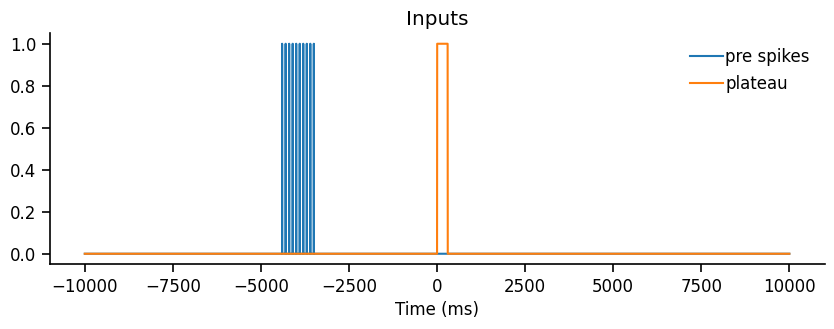

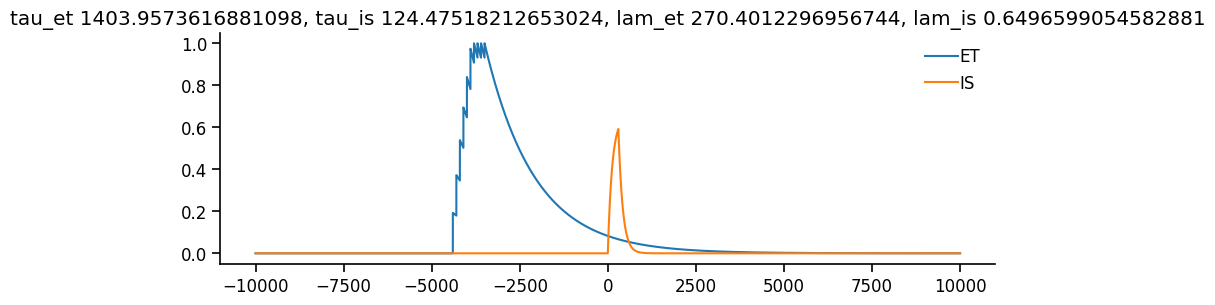

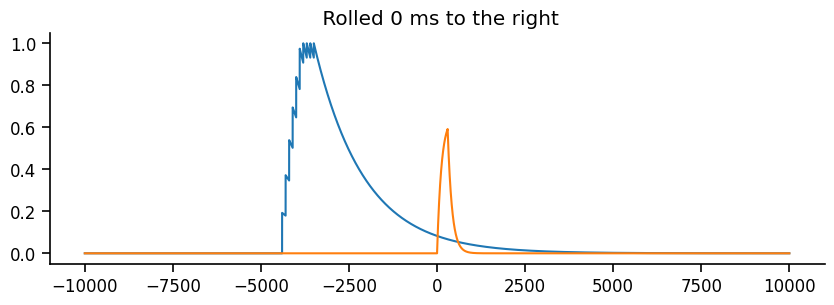

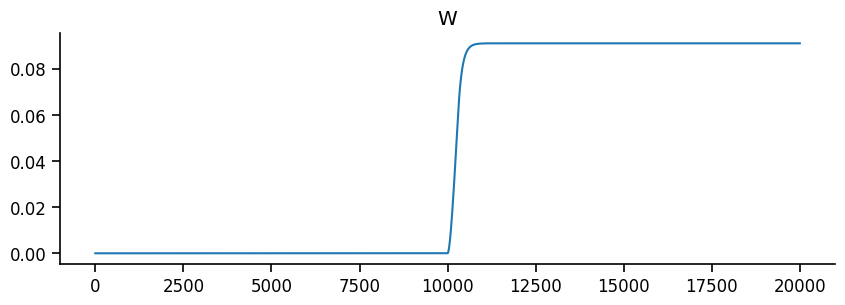

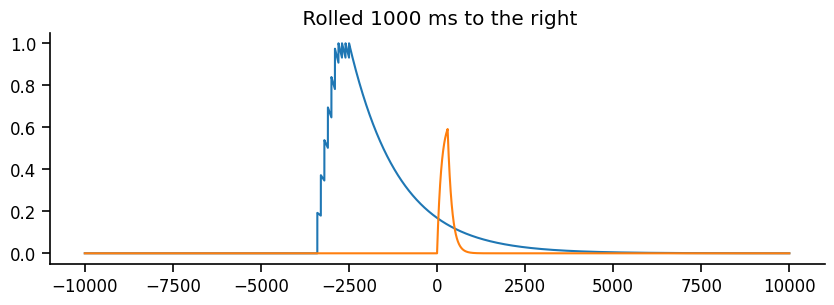

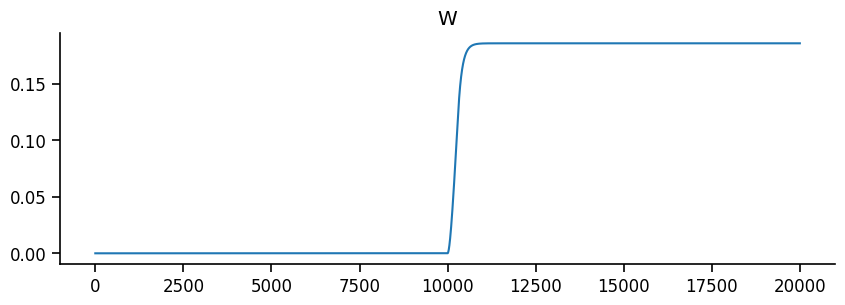

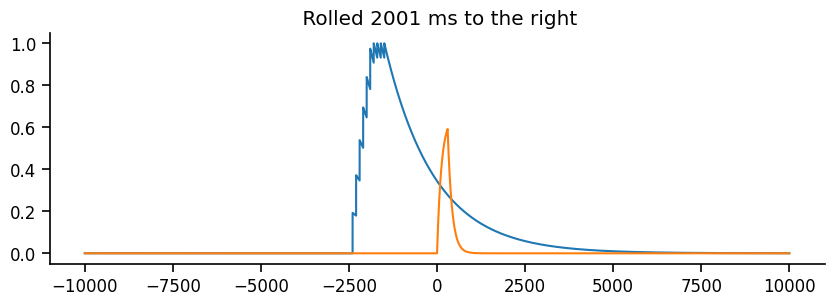

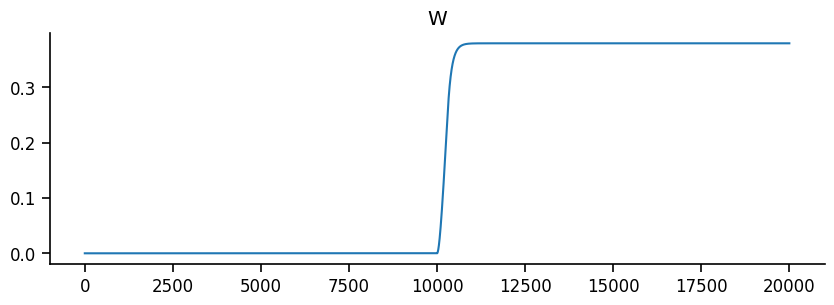

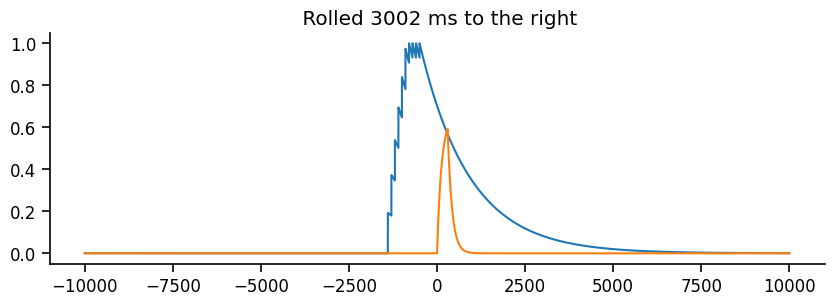

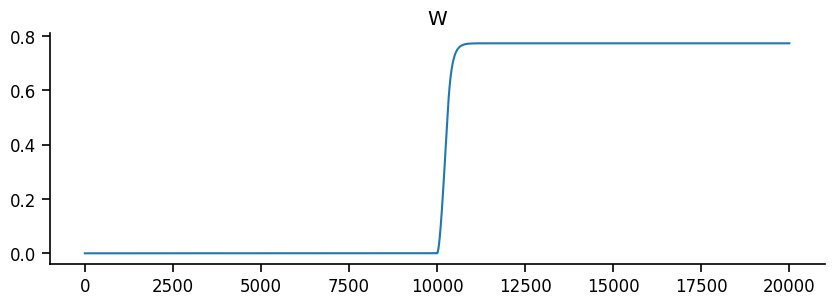

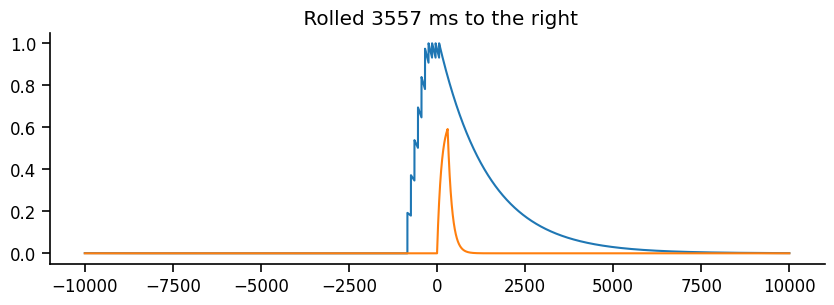

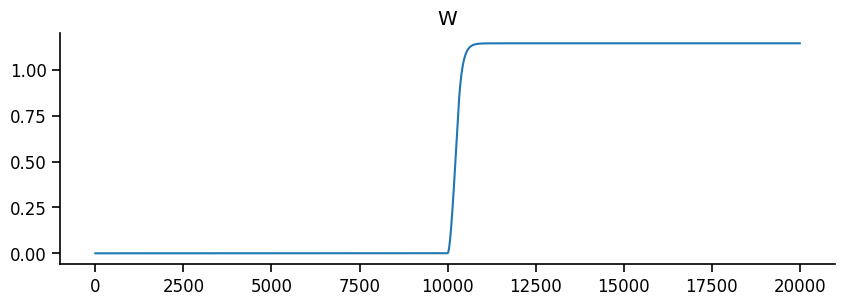

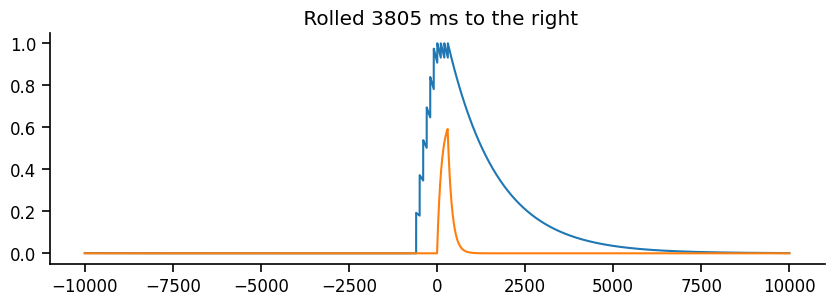

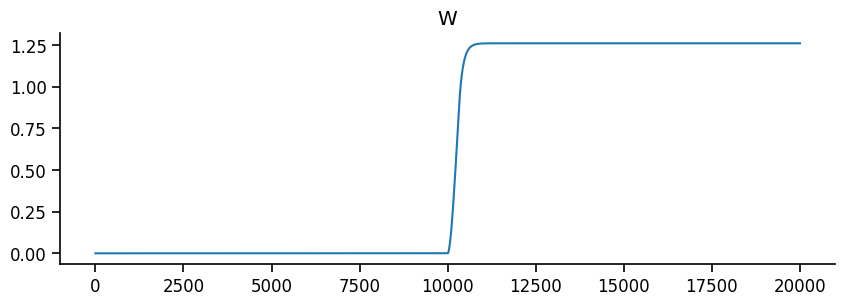

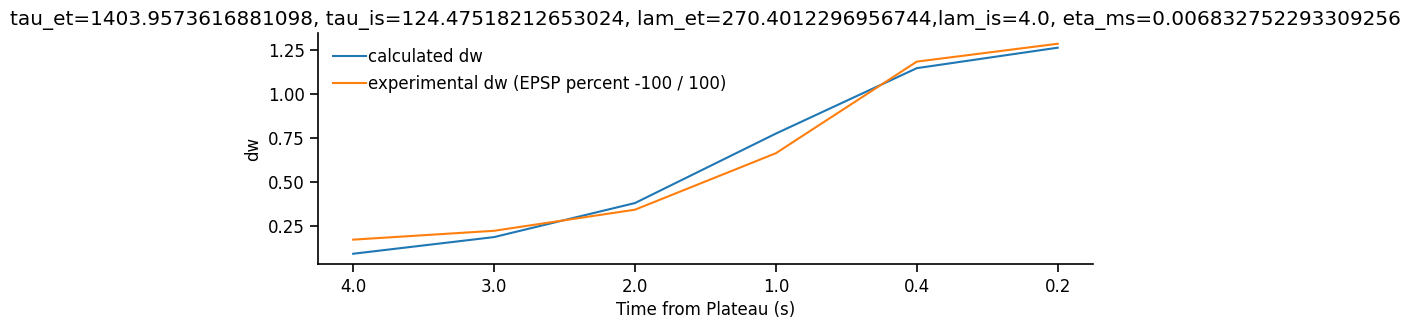

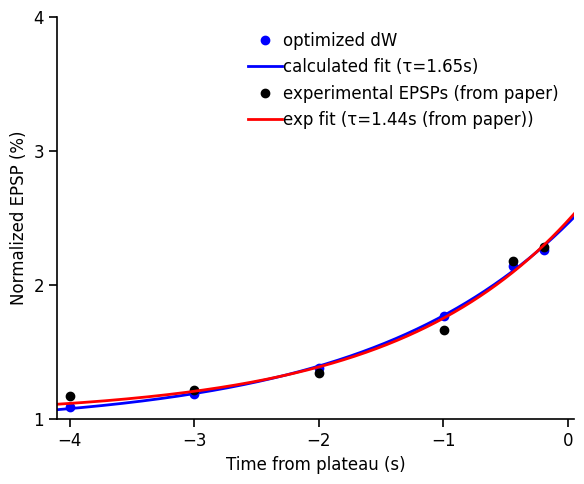

In [ ]:

# --- helpers ---
def fit_A_c_fixed_tau(x, y, tau):
    Phi = np.column_stack([np.exp(x/tau), np.ones_like(x)])
    A, c = np.linalg.lstsq(Phi, y, rcond=None)[0]
    return float(A), float(c)

def exp_rise(x, A, c, tau):
    return c + A*np.exp(x/tau)

def fit_tau_A_c(x, y, tau_min=0.1, tau_max=5.0, n_grid=600):
    taus = np.linspace(tau_min, tau_max, n_grid)
    best = (np.inf, None, None, None)
    for tau in taus:
        A, c = fit_A_c_fixed_tau(x, y, tau)
        sse = np.sum((y - exp_rise(x, A, c, tau))**2)
        if sse < best[0]:
            best = (sse, tau, A, c)
    _, tau_hat, A_hat, c_hat = best
    return tau_hat, A_hat, c_hat


def plot_best(study, df_10):

    best = study.best_params
    print(best)

    x_arr = (df_10["x"].to_numpy() * -1000).astype(int)  
    y_arr = df_10["y"].to_numpy()
    experimental_dW = y_arr * 100 - 100                  

    preds = np.empty_like(experimental_dW, dtype=float)

    delta_w_list_best = get_W(x_arr_int, post_ms=10000, pre_ms=10000, hz_used=10, plateau_length = 300,tau_et =best["tau_et"],tau_is = best["tau_is"],lam_et=best["lam_et"],lam_is=best["lam_is"],dt_ms=1.0, eta_ms = best["eta_ms"], plot_intermediates=True)


    y_arr = df_10["y"].to_numpy()
    y_arr_scaled = (y_arr-1)
    plt.plot(delta_w_list, label='calculated dw')
    plt.plot(y_arr_scaled, label='experimental dw (EPSP percent -100 / 100)')
    x_labels = [f"{val:.1f}" for val in x_arr_scaled_down]
    plt.xticks(range(len(x_labels)), x_labels)
    plt.xlabel("Time from Plateau (s)")
    plt.ylabel("dw")
    plt.title(f'tau_et={best["tau_et"]}, tau_is={best["tau_is"]}, lam_et={best["lam_et"]},lam_is={lam_is}, eta_ms={best["eta_ms"]}')
    plt.legend()


    # --- data (10 Hz) ---
    x = df_10["x"].to_numpy(float)          # seconds, negative→0
    y_exp = df_10["y"].to_numpy(float)      # experimental
    y_model = np.array(delta_w_list_best) + 1.0  # your calc, offset to "normalized EPSP %"

    # sort by x (just in case)
    order = np.argsort(x)
    x, y_exp, y_model = x[order], y_exp[order], y_model[order]

    # --- fits ---
    tau_paper = 1.44   # seconds for the 10 Hz condition
    A_exp, c_exp = fit_A_c_fixed_tau(x, y_exp, tau_paper)

    tau_mod, A_mod, c_mod = fit_tau_A_c(x, y_model, tau_min=0.1, tau_max=5.0)

    xx = np.linspace(-4.1, 0.05, 500)
    yy_exp = exp_rise(xx, A_exp, c_exp, tau_paper)
    yy_mod = exp_rise(xx, A_mod, c_mod, tau_mod)

    # --- plot ---
    plt.figure(figsize=(6,5))
    plt.plot(x, y_model, 'bo', label='optimized dW')
    plt.plot(xx, yy_mod, '-', color='blue', lw=2, label=fr'calculated fit (τ={tau_mod:.2f}s)')
    plt.plot(x, y_exp, 'ko', label='experimental EPSPs (from paper)')
    plt.plot(xx, yy_exp, '-', color='red', lw=2, label=fr'exp fit (τ={tau_paper:.2f}s (from paper))')
    plt.xlim(-4.1, 0.05)
    plt.xticks([-4, -3, -2, -1, 0])
    plt.ylim(1., 4.)
    plt.yticks([1,2,3,4])
    plt.ylabel("Normalized EPSP (%)")
    plt.xlabel("Time from plateau (s)")
    plt.legend()
    plt.tight_layout()
    plt.show()




[3999, 2999, 1998, 997, 442, 194]

{'tau_et': 1409.2183197448487, 'tau_is': 66.8128200843145, 'lam_et': 44.940114343717845, 'lam_is': 5.0696508871963415, 'eta_ms': 0.021911890245884295}


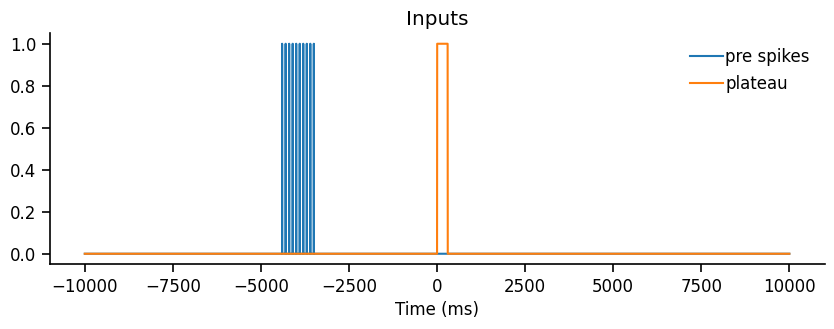

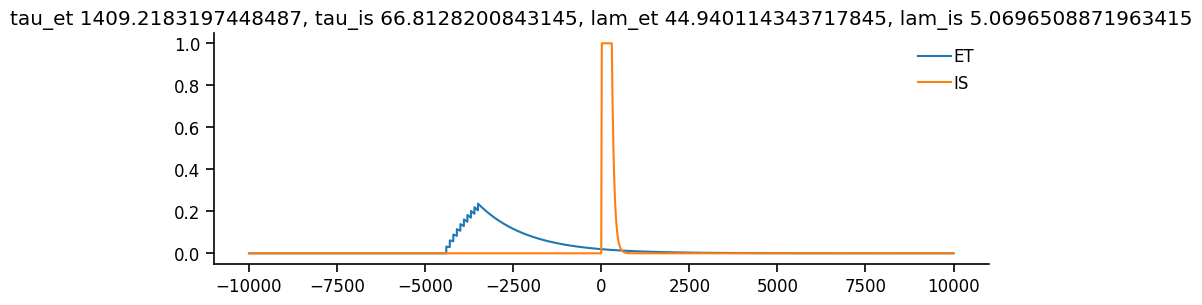

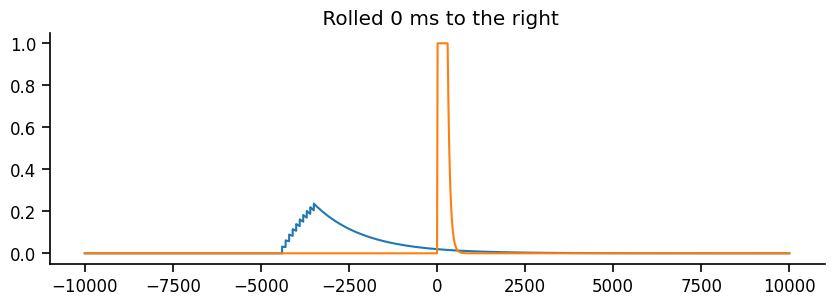

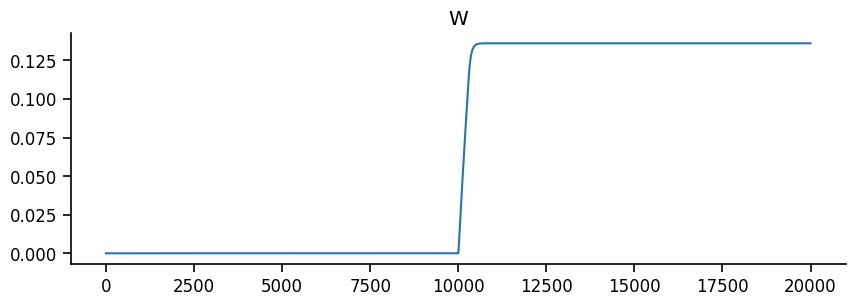

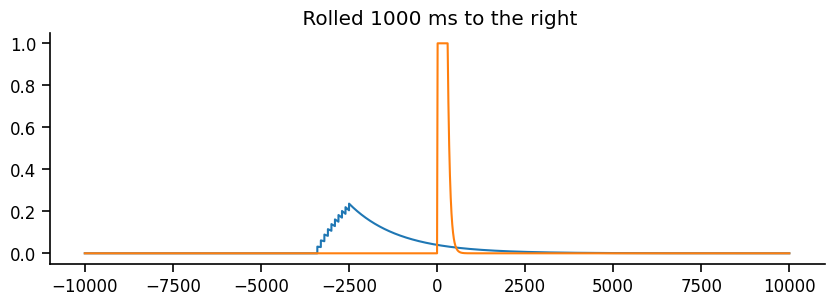

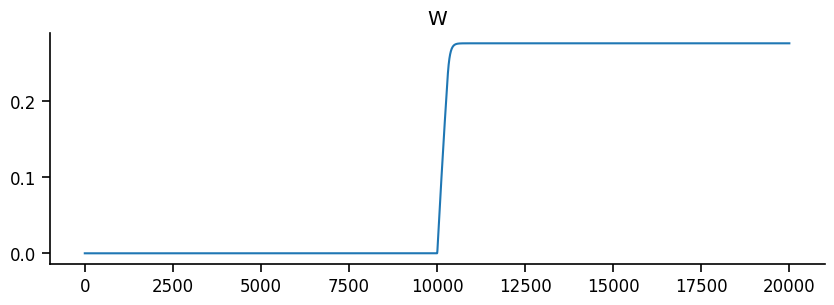

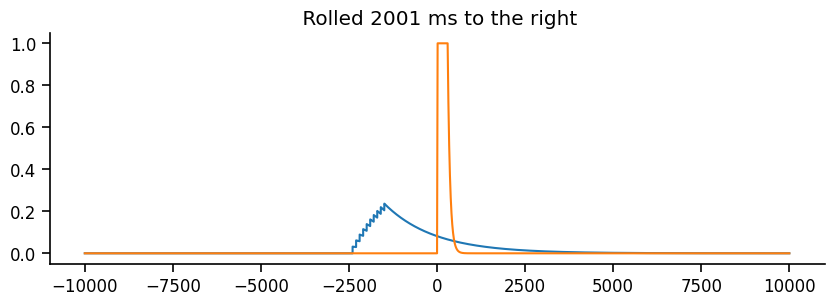

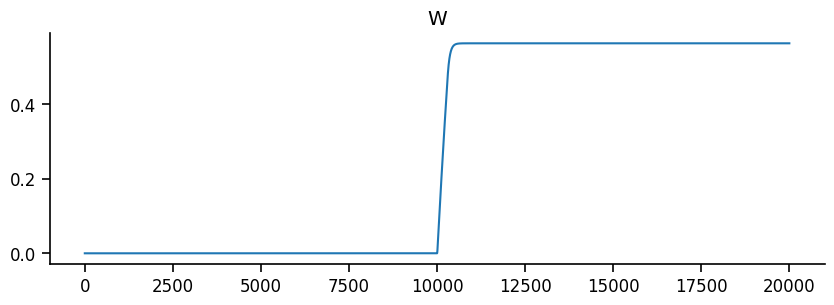

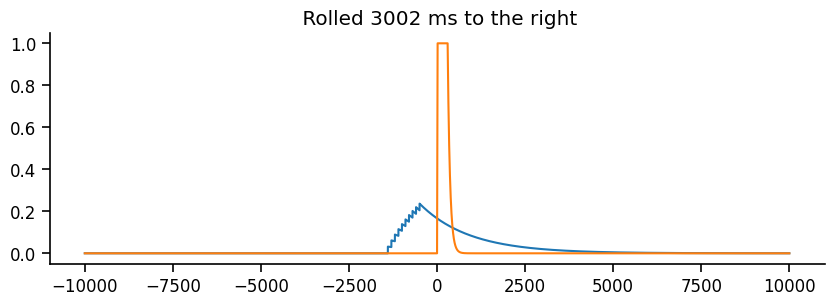

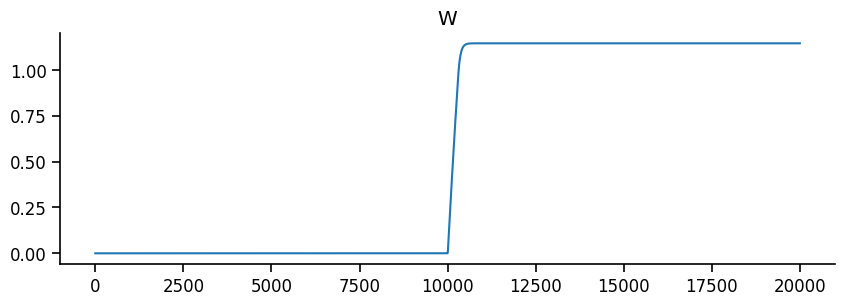

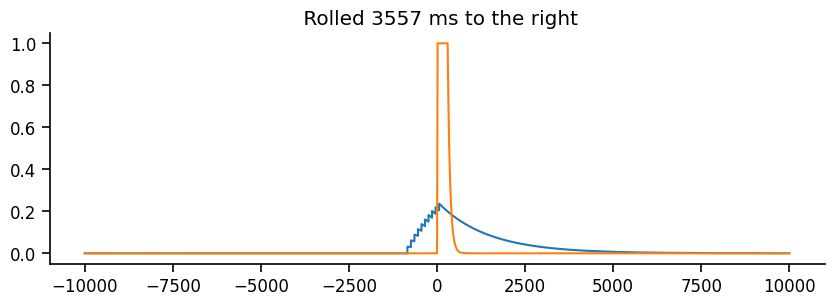

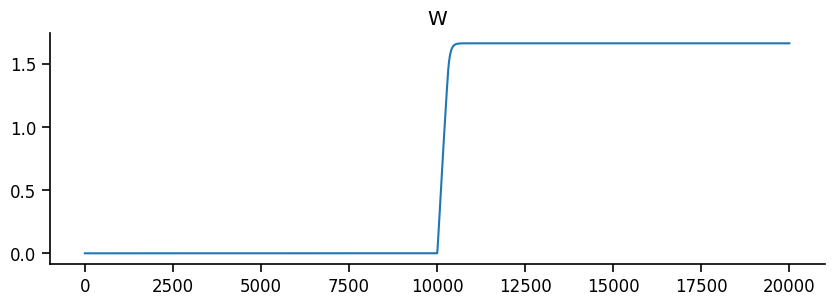

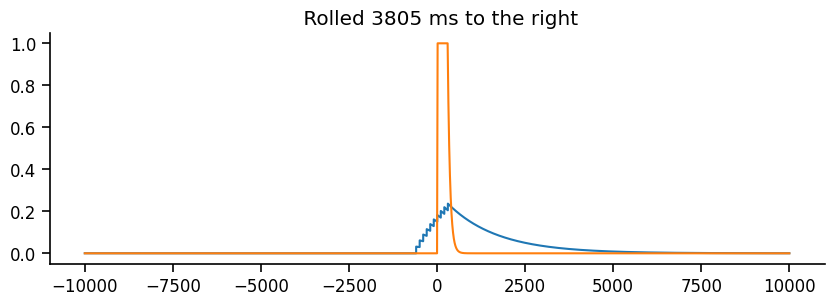

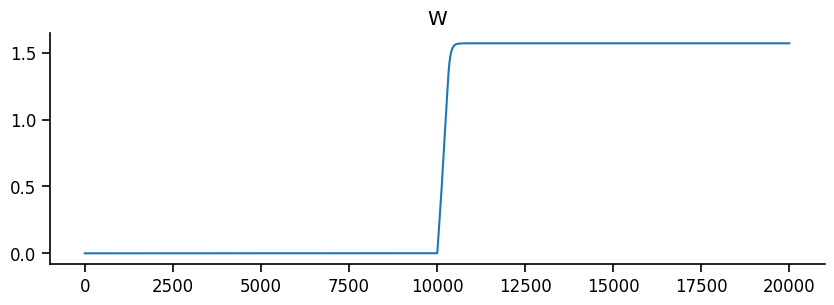

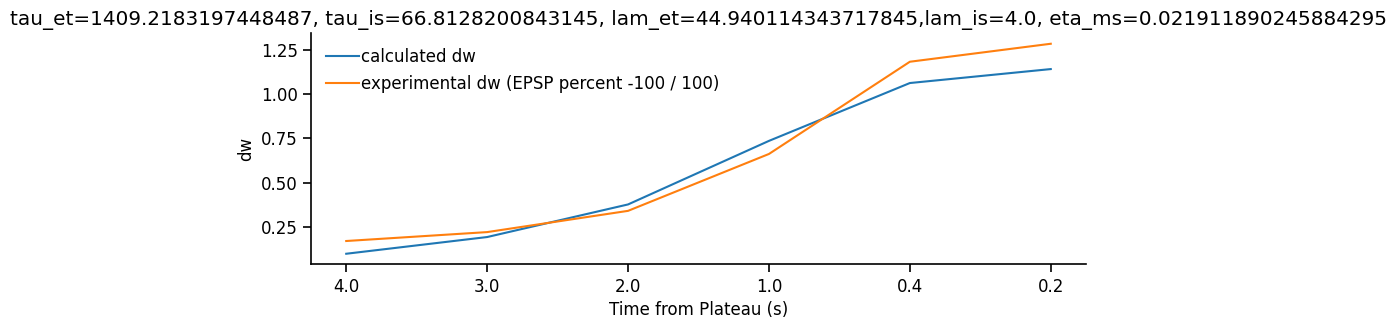

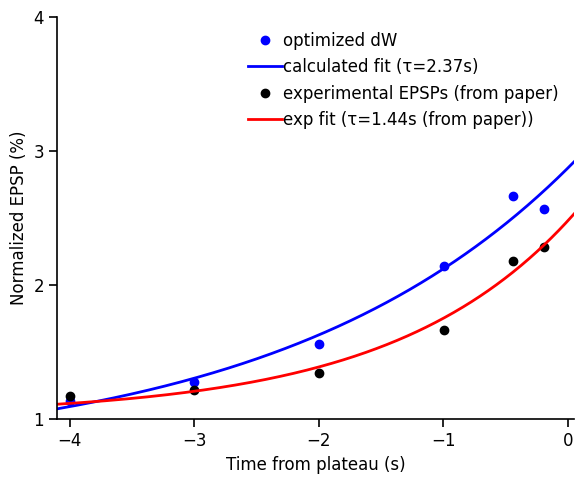

In [ ]:

def plot_best(study, df_10):

    best = study.best_params
    print(best)

    x_arr = (df_10["x"].to_numpy() * -1000).astype(int)  
    y_arr = df_10["y"].to_numpy()
    experimental_dW = y_arr * 100 - 100                  

    preds = np.empty_like(experimental_dW, dtype=float)

    delta_w_list_best = get_W(x_arr_int, post_ms=10000, pre_ms=10000, hz_used=10, plateau_length = 300,tau_et =best["tau_et"],tau_is = best["tau_is"],lam_et=best["lam_et"],lam_is=best["lam_is"],dt_ms=1.0, eta_ms = best["eta_ms"], plot_intermediates=False)


    y_arr = df_10["y"].to_numpy()
    y_arr_scaled = (y_arr-1)
    plt.plot(delta_w_list, label='calculated dw')
    plt.plot(y_arr_scaled, label='experimental dw (EPSP percent -100 / 100)')
    x_labels = [f"{val:.1f}" for val in x_arr_scaled_down]
    plt.xticks(range(len(x_labels)), x_labels)
    plt.xlabel("Time from Plateau (s)")
    plt.ylabel("dw")
    plt.title(f'tau_et={best["tau_et"]}, tau_is={best["tau_is"]}, lam_et={best["lam_et"]},lam_is={lam_is}, eta_ms={best["eta_ms"]}')
    plt.legend()


    # --- data (10 Hz) ---
    x = df_10["x"].to_numpy(float)          # seconds, negative→0
    y_exp = df_10["y"].to_numpy(float)      # experimental
    y_model = np.array(delta_w_list_best) + 1.0  # your calc, offset to "normalized EPSP %"

    # sort by x (just in case)
    order = np.argsort(x)
    x, y_exp, y_model = x[order], y_exp[order], y_model[order]

    # --- fits ---
    tau_paper = 1.44   # seconds for the 10 Hz condition
    A_exp, c_exp = fit_A_c_fixed_tau(x, y_exp, tau_paper)

    tau_mod, A_mod, c_mod = fit_tau_A_c(x, y_model, tau_min=0.1, tau_max=5.0)

    xx = np.linspace(-4.1, 0.05, 500)
    yy_exp = exp_rise(xx, A_exp, c_exp, tau_paper)
    yy_mod = exp_rise(xx, A_mod, c_mod, tau_mod)

    # --- plot ---
    plt.figure(figsize=(6,5))
    plt.plot(x, y_model, 'bo', label='optimized dW')
    plt.plot(xx, yy_mod, '-', color='blue', lw=2, label=fr'calculated fit (τ={tau_mod:.2f}s)')
    plt.plot(x, y_exp, 'ko', label='experimental EPSPs (from paper)')
    plt.plot(xx, yy_exp, '-', color='red', lw=2, label=fr'exp fit (τ={tau_paper:.2f}s (from paper))')
    plt.xlim(-4.1, 0.05)
    plt.xticks([-4, -3, -2, -1, 0])
    plt.ylim(1., 4.)
    plt.yticks([1,2,3,4])
    plt.ylabel("Normalized EPSP (%)")
    plt.xlabel("Time from plateau (s)")
    plt.legend()
    plt.tight_layout()
    plt.show()


df_list = [df_10, df_20, df_40, df_100]

plot_best(study_all_concat, df_10)

In [ ]:
import os
from math import ceil
from functools import partial
import optuna
from multiprocessing import get_context

# --- your existing lists ---
dfs_list = [df_10, df_20, df_40, df_100]
rates_hz  = [10, 20, 40, 100]

# IMPORTANT on Macs + NumPy/BLAS: avoid thread oversubscription
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")

STORAGE_URL = "sqlite:///et_is_optuna_all_concat.db"
STUDY_NAME  = "et_is_fit_all_concat"


def objective(trial, rates_hz, dfs_list):
    params = {
        "tau_et": trial.suggest_float("tau_et", 50.0, 3000.0, log=True),
        "tau_is": trial.suggest_float("tau_is", 50.0, 2000.0, log=True),
        "lam_et": trial.suggest_float("lam_et", 0.1, 500.0, log=True),
        "lam_is": trial.suggest_float("lam_is", 0.1, 50.0,  log=True),
        "eta_ms": trial.suggest_float("eta_ms", 1e-5, 5e-2, log=True),   
    }

    y_exp_list = []
    y_calculated_list = []

    for i in range(len(dfs_list)):
        experimental_data = dfs_list[i]
        hz_used = rates_hz[i]

        y_exp = experimental_data["y"].to_numpy(float)
        y_exp_scaled_to_w = [data-1 for data in y_exp]
        y_exp_array = np.array(y_exp_scaled_to_w)
        y_exp_list.append(y_exp_array)

        x_arr = experimental_data["x"].to_numpy() *-1000
        x_arr_int = [int(x) for x in x_arr]

        delta_w_list = get_W(x_arr_int, post_ms=10000, pre_ms=10000, hz_used=hz_used, plateau_length=300,tau_et=params["tau_et"], tau_is=params["tau_is"],lam_et=params["lam_et"], lam_is=params["lam_is"],dt_ms=1.0, eta_ms=params["eta_ms"],plot_intermediates=False)
        y_pred_dw = np.array(delta_w_list)
        y_calculated_list.append(y_pred_dw)


    y_exp_array_all_data = np.hstack(y_exp_list)
    y_calulated_array_all_data = np.hstack(y_calculated_list)

    loss = float(np.mean((y_calulated_array_all_data - y_exp_array_all_data)**2))
    return loss

def worker(n_trials, seed, dfs_list, rates_hz):
    sampler = optuna.samplers.TPESampler(seed=seed, multivariate=True)
    study = optuna.create_study(
        study_name=STUDY_NAME,
        storage=STORAGE_URL,
        load_if_exists=True,
        direction="minimize",
        sampler=sampler,
    )
    study.optimize(
        partial(objective, dfs_list=dfs_list, rates_hz=rates_hz),
        n_trials=n_trials,
        show_progress_bar=False,    
        gc_after_trial=True,
    )

if __name__ == "__main__":
    total_trials = 15000
    n_workers    = 4   # set to number of CPU cores you want to use

    trials_per_worker = ceil(total_trials / n_workers)

    # spawn is safest on macOS
    ctx = get_context("spawn")
    procs = []
    for w in range(n_workers):
        p = ctx.Process(
            target=worker,
            args=(trials_per_worker, 42 + w, dfs_list, rates_hz),
            daemon=False,
        )
        p.start()
        procs.append(p)
    for p in procs:
        p.join()

    # After workers finish, load best result once
    study = optuna.load_study(study_name=STUDY_NAME, storage=STORAGE_URL)
    print("Best:", study.best_value, study.best_params)


In [199]:
pwd

'/Users/michaelfinch/Downloads'

In [ ]:
##### works 


import numpy as np
import matplotlib.pyplot as plt

def integrate_weight(ET, IS, eta_ms=1e-4, Wmin=0.0, Wmax=2.0, dt_ms=1.0):
    """
    Integrate dW/dt = eta * ET * IS using a left-rectangle rule.
    Units:
      - eta_ms is 'per ms' (same as your original code)
      - dt_ms in ms
    """
    T = len(ET)
    W = np.empty(T, dtype=float)
    w = 0.0
    for t in range(T):
        dWdt = eta_ms * ET[t] * IS[t]
        w += dWdt * dt_ms            # <-- dt in ms, matches eta_ms units
        w = np.clip(w, Wmin, Wmax)
        W[t] = w
    return W

def multiply_et(u, tau_ms, lam=1.0, dt_ms=1.0, cap=1.0):
    """
    Exact discrete update for dE/dt = (-E + lam*u)/tau, piecewise-constant u.
    Keeps your signature and returns an array the same size as u.
    """
    T = len(u)
    E = np.empty_like(u, dtype=float)
    a = np.exp(-dt_ms / tau_ms)       # exact decay per step
    Em = 0.0
    for t in range(T):
        Em = a * Em + (1.0 - a) * lam * u[t]
        if cap is not None:
            Em = min(cap, Em)         # keep your old cap behavior
        E[t] = Em
    return E

def get_W(x_arr_int, *,
          post_ms=10000, pre_ms=10000, hz_used=10,
          plateau_length=300,
          tau_et=1500., tau_is=500.,
          lam_et=200., lam_is=4.,
          dt_ms=1.0, eta_ms=0.0001,
          plot_intermediates=True):
    """
    Same API as yours, but all arrays are built on a dt_ms grid.
    - x_arr_int: list of shifts in ms (negative to near zero)
    """
    # ---- time grid on dt_ms steps ----
    T_ms = float(pre_ms + post_ms)
    n_steps = int(np.round(T_ms / dt_ms))
    t_ms = np.arange(-pre_ms, post_ms, dt_ms)  # length n_steps
    assert len(t_ms) == n_steps

    center_idx = int(np.round(pre_ms / dt_ms))  # index of time 0 on the grid

    # ---- build pre spikes on the same grid ----
    spike_times_ms = spike_train_by_rate(rate_hz=hz_used, n=10, t0_ms=0).astype(float)
    mid_spike = spike_times_ms[4]

    time_to_is = float(x_arr_int[0])  # ms
    offset_ms = (center_idx * dt_ms) - time_to_is - mid_spike
    spike_idx_steps = np.round((offset_ms + spike_times_ms) / dt_ms).astype(int)

    spike_train = np.zeros(n_steps, dtype=float)
    valid = (spike_idx_steps >= 0) & (spike_idx_steps < n_steps)
    spike_train[spike_idx_steps[valid]] = 1.0

    # ---- plateau on the grid ----
    is_pre_conv = np.zeros(n_steps, dtype=float)
    p0 = center_idx
    p1 = int(np.round((pre_ms + plateau_length) / dt_ms))
    p1 = np.clip(p1, 0, n_steps)
    is_pre_conv[p0:p1] = 1.0

    if plot_intermediates:
        plt.plot(t_ms, spike_train, label='pre spikes')
        plt.plot(t_ms, is_pre_conv, label='plateau')
        plt.title("Inputs")
        plt.xlabel("Time (ms)")
        plt.legend()
        plt.show()

    # ---- traces (dt-agnostic exact update) ----
    ET = multiply_et(spike_train, tau_ms=tau_et, lam=lam_et, dt_ms=dt_ms, cap=1.0)
    IS = multiply_et(is_pre_conv,  tau_ms=tau_is, lam=lam_is, dt_ms=dt_ms, cap=1.0)

    if plot_intermediates:
        plt.plot(t_ms, ET, label="ET")
        plt.plot(t_ms, IS, label="IS")
        plt.title(f"tau_et {tau_et}, tau_is {tau_is}, lam_et {lam_et}, lam_is {lam_is}")
        plt.legend()
        plt.show()

    # ---- compute cumulative shifts (in ms) and convert to steps ----
    x_arr_diff = np.diff(x_arr_int)
    cumulative_rolls_ms = np.concatenate(([0], np.cumsum(x_arr_diff)))
    # roll direction: your code used abs; keep behavior
    delta_w_list = []

    for roll_ms in np.abs(cumulative_rolls_ms):
        roll_steps = int(np.round(roll_ms / dt_ms))          # convert ms -> steps
        ET_rolled = np.roll(ET, roll_steps)

        if plot_intermediates:
            plt.plot(t_ms, ET_rolled, label="ET Rolled")
            plt.plot(t_ms, IS,        label="IS")
            plt.title(f"Rolled {roll_ms:.0f} ms → {roll_steps} steps")
            plt.legend()
            plt.show()

        # integrate once (optionally unclipped like you did)
        # W = integrate_weight(ET_rolled, IS, eta_ms=eta_ms, Wmin=0.0, Wmax=5.0, dt_ms=dt_ms)
        W = integrate_weight(ET_rolled, IS, eta_ms=eta_ms, Wmin=-np.inf, Wmax=np.inf, dt_ms=dt_ms)

        if plot_intermediates:
            plt.plot(np.arange(n_steps)*dt_ms - pre_ms, W)
            plt.title("W")
            plt.xlabel("Time (ms)")
            plt.show()

        delta_w_list.append(W[-1] - W[0])

    return delta_w_list


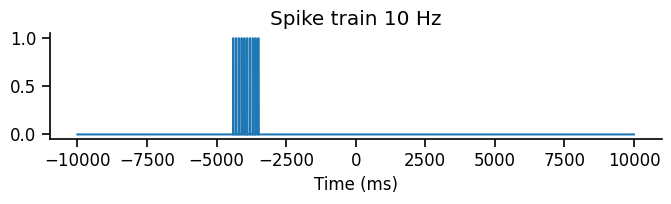

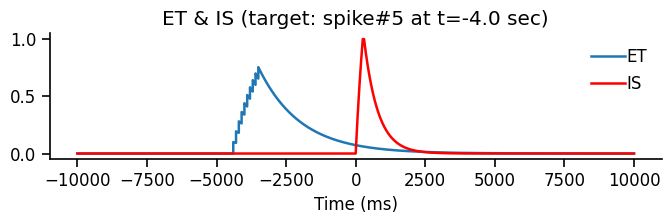

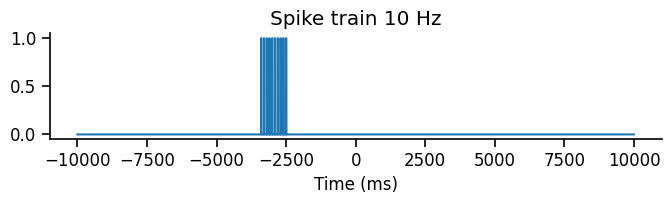

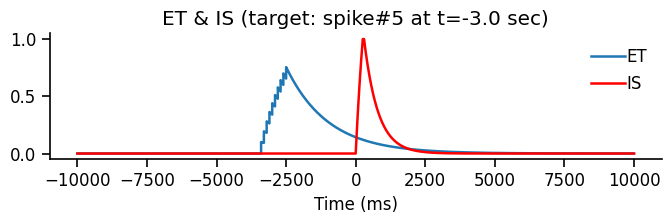

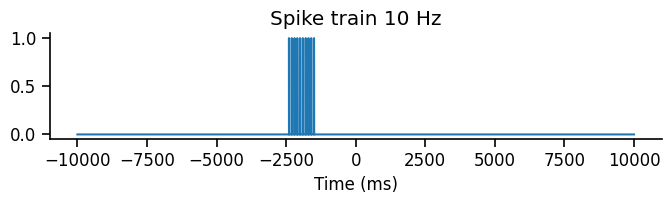

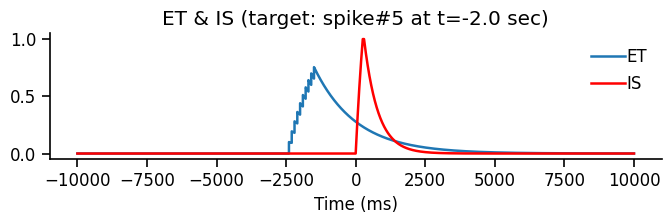

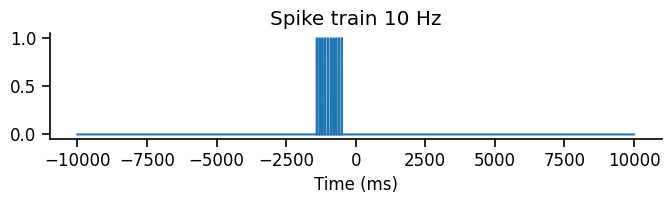

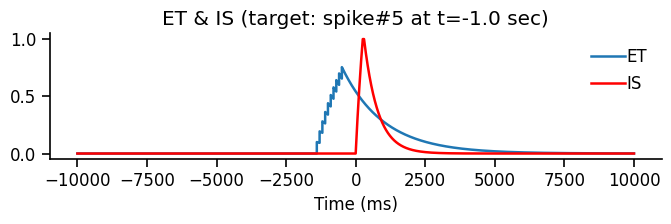

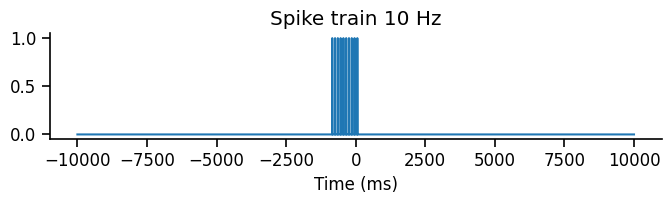

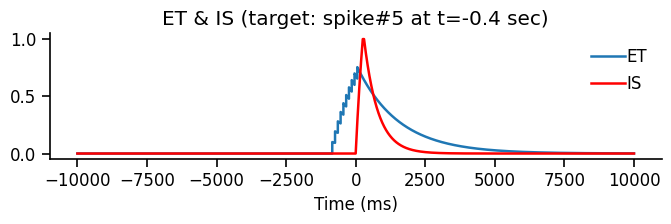

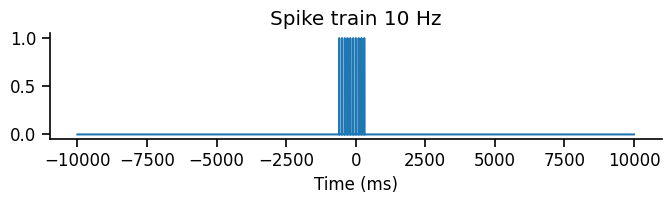

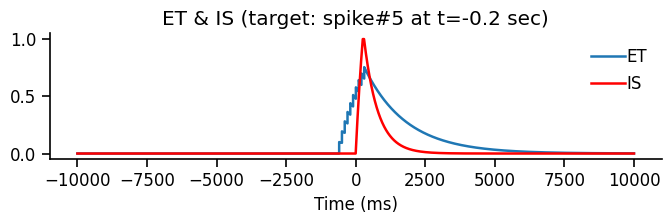

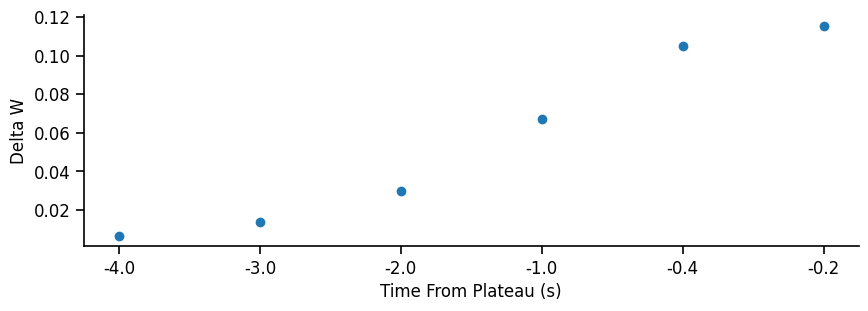

In [ ]:
def et_min_rule(spikes, tau_ms=20.0, lam=1.0, dt_ms=1.0):
    alpha = np.exp(-dt_ms / tau_ms)
    ET = 0.0
    overall_ETs = np.empty_like(spikes, dtype=float)
    for i, s in enumerate(spikes):
        ET *= alpha
        ET += min(1.0 - ET, lam * s)
        overall_ETs[i] = ET
    return overall_ETs


def get_et_is(hz_used=10, time_to_is=1000, post_ms=10000, pre_ms=10000, tau_et=20., tau_is=20., lam_et=1.0, lam_is=1.0, show_intermediates=True):

    spike_times = spike_train_by_rate(rate_hz=hz_used, n=10, t0_ms=0).astype(int)
    mid_spike = spike_times[4]

    T_ms = int(pre_ms + post_ms)
    t_ms = np.arange(-pre_ms, post_ms, dtype=int)
    center_idx = pre_ms  

    offset = center_idx - time_to_is - mid_spike
    spike_idx = offset + spike_times

    spike_train = np.zeros(T_ms, dtype=float)
    valid = (spike_idx >= 0) & (spike_idx < T_ms)
    spike_train[spike_idx[valid]] = 1.0

    is_time = np.zeros(T_ms, dtype=float)
    is_start = center_idx
    is_end = min(center_idx + 300, T_ms)
    is_time[is_start:is_end] = 1.0

    ET = et_min_rule(spike_train, tau_ms=tau_et, lam=lam_et, dt_ms=1.0)
    IS = et_min_rule(is_time,    tau_ms=tau_is, lam=lam_is, dt_ms=1.0)

    if show_intermediates:
        plt.figure(figsize=(7, 2.2))
        # plt.plot(t_ms[9000:11000], spike_train[9000:11000], drawstyle="steps-post")
        plt.plot(t_ms, spike_train, drawstyle="steps-post")
        plt.title(f"Spike train {hz_used} Hz")
        plt.xlabel("Time (ms)")
        plt.tight_layout(); plt.show()

        plt.figure(figsize=(7, 2.4))
        plt.plot(t_ms, ET, lw=1.8, label='ET')
        plt.plot(t_ms, IS, lw=1.8, label='IS', color='r')
        plt.title(f"ET & IS (target: spike#5 at t={-time_to_is/1000:.1f} sec)")
        plt.xlabel("Time (ms)")
        plt.legend(); plt.tight_layout(); plt.show()

    return ET, IS

dw_list = []
x_arr = df_10["x"].to_numpy() *-1000
for i in x_arr:
    ET, IS = get_et_is(hz_used = 10, time_to_is = int(i), post_ms=10000, pre_ms=10000, tau_et =1500., tau_is = 500., lam_et=0.1, lam_is=0.005, show_intermediates=True)
    Wmax=5
    # w_init = np.arange(0, Wmax, 0.05)
    dW_pred_i = multiW_btsp(ET, IS, W=0, Wmax=Wmax)
    dw_list.append(dW_pred_i)

plt.plot(dw_list, marker='o', linestyle="None")
plt.ylabel("Delta W")
x_labels = [f"{val:.1f}" for val in x_arr / -1000]
plt.xticks(range(len(x_arr)), x_labels)
plt.xlabel("Time From Plateau (s)")
plt.show()


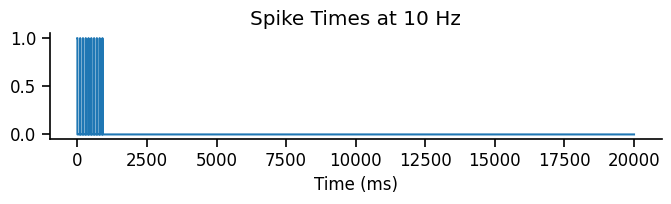

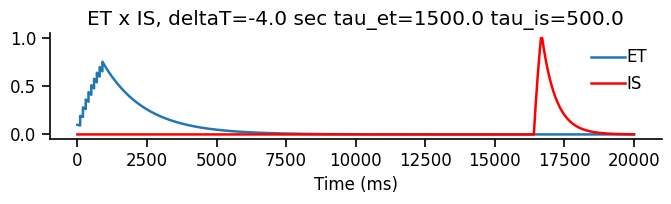

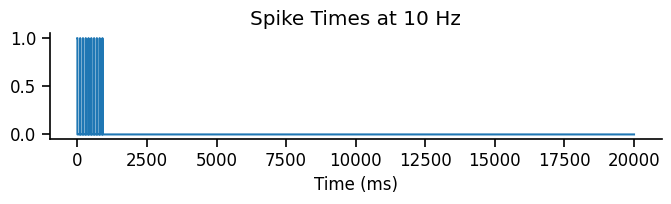

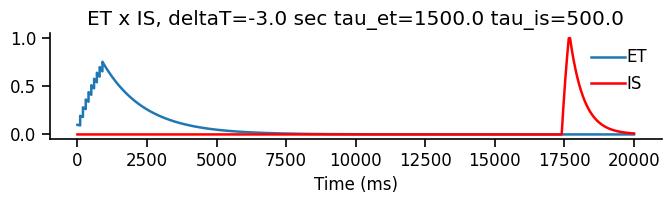

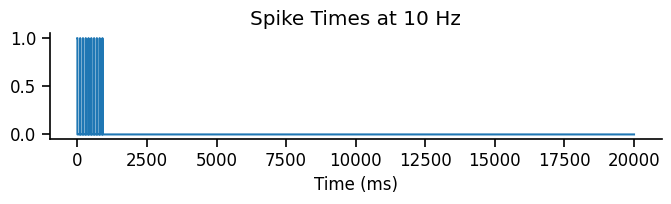

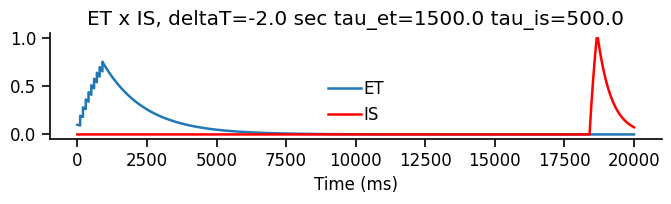

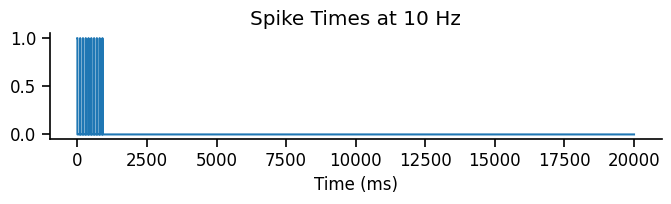

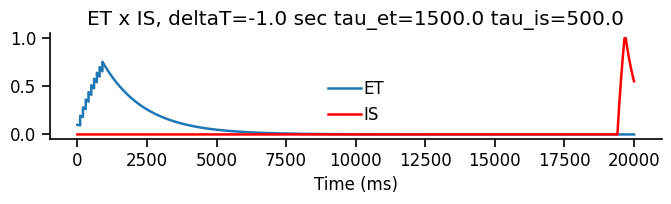

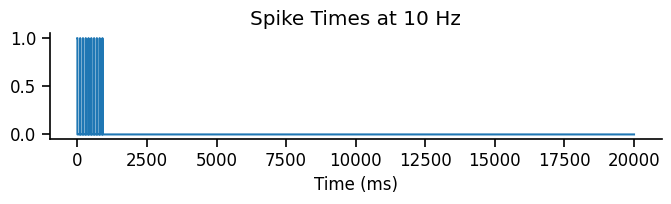

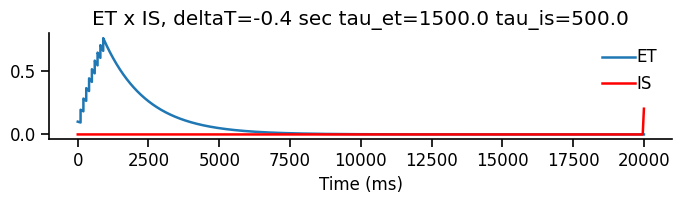

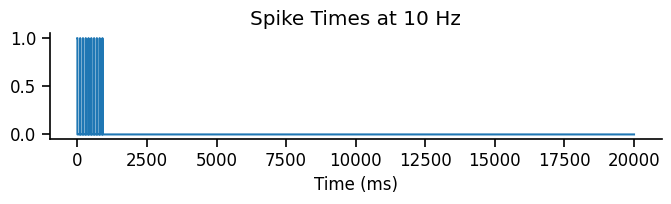

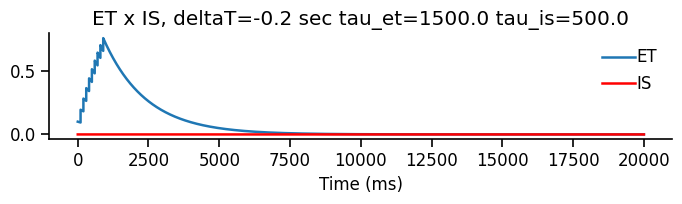

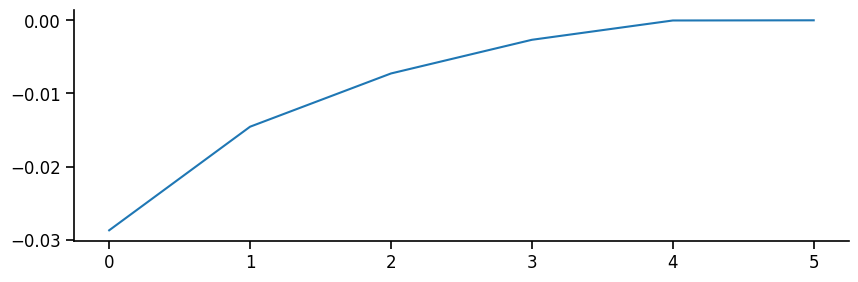

In [ ]:
def et_min_rule(spikes, tau_ms=20.0, lam=1.0, dt_ms=1.0):
    alpha = np.exp(-dt_ms / tau_ms)
    ET = 0.0
    overall_ETs = np.empty_like(spikes, dtype=float)
    for i, s in enumerate(spikes):
        ET *= alpha
        ET += min(1.0 - ET, lam * s)  
        overall_ETs[i] = ET
    return overall_ETs

def get_et_is(hz_used = 10, time_to_is = 1000, post_ms= 10000, pre_ms= 10000, tau_et = 20., tau_is = 20., lam_et=1.0, lam_is=1.0, show_intermediates = True):
    spike_times = spike_train_by_rate(rate_hz=hz_used, n=10, t0_ms=0).astype(int)

    time_middle_to_is = post_ms - (time_to_is + spike_times[5])

    T_ms = int(pre_ms + post_ms)
    t_ms = pre_ms + (np.arange(T_ms) - (T_ms - 1)) + post_ms   

    spike_train = np.zeros(T_ms, dtype=float)
    valid = spike_times[(spike_times >= 0) & (spike_times < T_ms)]
    spike_train[valid] = 1.0

    if show_intermediates:
        plt.figure(figsize=(7, 2.2))
        plt.plot(t_ms, spike_train, drawstyle="steps-post")
        plt.title(f"Spike Times at {hz_used} Hz")
        plt.xlabel("Time (ms)")
        # plt.xlim(t_ms[0]-20, post_ms)   # include +post_ms
        plt.tight_layout()
        plt.show()

    # kernel_et = exp_kernel(tau_ms=tau_et, dt_ms=1.0, n_taus=5, norm="area", target=1.0)
    # ET = np.convolve(spike_train, kernel_et, mode="full")[:T_ms]

    is_time = np.zeros(t_ms.shape)
    time_to_zero = pre_ms + spike_times.max() + time_middle_to_is
    is_time[time_to_zero:(time_to_zero+300)] = 1
    # kernel_is = exp_kernel(tau_ms=tau_is, dt_ms=1.0, n_taus=5, norm="area", target=1.0)

    # IS = np.convolve(is_time, kernel_is, mode="full")[:T_ms]


    ET = et_min_rule(spike_train, tau_ms=tau_et, lam=lam_et, dt_ms=1.0)
    IS = et_min_rule(is_time,    tau_ms=tau_is, lam=lam_is, dt_ms=1.0)


    if show_intermediates:
        plt.figure(figsize=(7, 2.2))
        plt.plot(t_ms, ET, lw=1.8, label='ET')
        plt.title(f"ET x IS, deltaT={-time_to_is/1000:.1f} sec tau_et={tau_et:.1f} tau_is={tau_is:.1f}")
        plt.xlabel("Time (ms)")
        # plt.xlim(t_ms[0]-20, post_ms)
        plt.plot(t_ms, IS, lw=1.8, color='red', label="IS")
        plt.legend()
        plt.tight_layout()
        plt.show()

    return ET, IS

dw_list = []
x_arr = df_10["x"].to_numpy() *-1000
for i in x_arr:
    ET, IS = get_et_is(hz_used = 10, time_to_is = int(i), post_ms=10000, pre_ms=10000, tau_et =1500., tau_is = 500., lam_et=0.1, lam_is=0.005, show_intermediates = True)
    dW_pred_i = btsp(ET, IS, W=1, Wmax=2)
    dw_list.append(dW_pred_i)

plt.plot(dw_list)


In [ ]:

def exp_kernel_area1(tau_ms, dt_ms=1.0, n_taus=5):
    """Single-exponential kernel with unit area (step input → steady 1)."""
    alpha = np.exp(-dt_ms / tau_ms)
    lam_k = 1.0 - alpha                 # area = 1
    L = int(np.ceil(n_taus * tau_ms / dt_ms))
    n = np.arange(L, dtype=float)
    return lam_k * (alpha ** n)         # k[n] = (1-α) α^n

def ln_trace(stim, tau_ms=20.0, dt_ms=1.0, lam=1.0):
    """
    L: y_lin = stim * k  (conv with exp kernel, area=1)
    N: y = 1 - exp(-lam * y_lin)  (smooth cap in [0,1])
    For small inputs, y ≈ lam * y_lin (like linear gain λ); as y grows, it saturates to 1.
    """
    k = exp_kernel_area1(tau_ms, dt_ms)
    y_lin = np.convolve(stim.astype(float), k, mode="full")[:len(stim)]
    return 1.0 - np.exp(-lam * y_lin)   # bounded in [0,1]

def ln_trace_hardclip(stim, tau_ms=20.0, dt_ms=1.0, lam=1.0):
    k = exp_kernel_area1(tau_ms, dt_ms)
    y_lin = lam * np.convolve(stim.astype(float), k, mode="full")[:len(stim)]
    return np.minimum(1.0, y_lin)       # cap at 1


    # else:
    #     if mode == "smooth":
    #         ET = ln_trace(spike_train, tau_ms=tau_et, dt_ms=1.0, lam=lam_et)
    #         IS = ln_trace(is_time,      tau_ms=tau_is, dt_ms=1.0, lam=lam_is)
    #     elif mode == "hard":
    #         ET = ln_trace_hardclip(spike_train, tau_ms=tau_et, dt_ms=1.0, lam=lam_et)
    #         IS = ln_trace_hardclip(is_time,      tau_ms=tau_is, dt_ms=1.0, lam=lam_is)